In [1]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment2/'
FOLDERNAME = 'cs231n/assignments/assignment2/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

Mounted at /content/drive
/content/drive/My Drive/cs231n/assignments/assignment2/cs231n/datasets
/content/drive/My Drive/cs231n/assignments/assignment2


# Multi-Layer Fully Connected Network
In this exercise, you will implement a fully connected network with an arbitrary number of hidden layers.

Read through the `FullyConnectedNet` class in the file `cs231n/classifiers/fc_net.py`.

Implement the network initialization, forward pass, and backward pass. Throughout this assignment, you will be implementing layers in `cs231n/layers.py`. You can re-use your implementations for `affine_forward`, `affine_backward`, `relu_forward`, `relu_backward`, and `softmax_loss` from Assignment 1. For right now, don't worry about implementing dropout or batch/layer normalization yet, as you will add those features later.


In [2]:
# Setup cell.
import time
import numpy as np
import matplotlib.pyplot as plt
from cs231n.classifiers.fc_net import *
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # Set default size of plots.
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """Returns relative error."""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

=========== You can safely ignore the message below if you are NOT working on ConvolutionalNetworks.ipynb ===========
	You will need to compile a Cython extension for a portion of this assignment.
	The instructions to do this will be given in a section of the notebook below.


In [3]:
# Load the (preprocessed) CIFAR-10 data.
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


## Initial Loss and Gradient Check

As a sanity check, run the following to check the initial loss and to gradient check the network both with and without regularization. This is a good way to see if the initial losses seem reasonable.

For gradient checking, you should expect to see errors around 1e-7 or less.

In [ ]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
    print("Running check with reg = ", reg)
    model = FullyConnectedNet(
        [H1, H2],
        input_dim=D,
        num_classes=C,
        reg=reg,
        weight_scale=5e-2,
        dtype=np.float64
    )

    loss, grads = model.loss(X, y)
    print("Initial loss: ", loss)

    # Most of the errors should be on the order of e-7 or smaller.
    # NOTE: It is fine however to see an error for W2 on the order of e-5
    # for the check when reg = 0.0
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print(f"{name} relative error: {rel_error(grad_num, grads[name])}")

Running check with reg =  0
Initial loss:  2.3004790887705955
W1 relative error: 7.696805225884638e-08
W2 relative error: 1.0139831360521187e-05
W3 relative error: 3.8809075313354153e-07
b1 relative error: 7.588003489874129e-09
b2 relative error: 2.085654276112763e-09
b3 relative error: 6.355520648828794e-10
Running check with reg =  3.14
Initial loss:  7.052114775533938
W1 relative error: 1.1358395917166688e-08
W2 relative error: 6.86942277940646e-08
W3 relative error: 3.483989247437803e-08
b1 relative error: 1.4752427965311745e-08
b2 relative error: 1.7223751746766738e-09
b3 relative error: 6.435910850375977e-10


As another sanity check, make sure your network can overfit on a small dataset of 50 images. First, we will try a three-layer network with 100 units in each hidden layer. In the following cell, tweak the **learning rate** and **weight initialization scale** to overfit and achieve 100% training accuracy within 20 epochs.

(Iteration 1 / 40) loss: 23.025851
(Epoch 0 / 20) train acc: 0.220000; val_acc: 0.114000
(Epoch 1 / 20) train acc: 0.360000; val_acc: 0.141000
(Epoch 2 / 20) train acc: 0.540000; val_acc: 0.142000
(Epoch 3 / 20) train acc: 0.680000; val_acc: 0.156000
(Epoch 4 / 20) train acc: 0.840000; val_acc: 0.170000
(Epoch 5 / 20) train acc: 0.880000; val_acc: 0.154000
(Iteration 11 / 40) loss: 1.842068
(Epoch 6 / 20) train acc: 0.940000; val_acc: 0.152000
(Epoch 7 / 20) train acc: 0.920000; val_acc: 0.146000
(Epoch 8 / 20) train acc: 0.960000; val_acc: 0.150000
(Epoch 9 / 20) train acc: 0.940000; val_acc: 0.142000
(Epoch 10 / 20) train acc: 0.980000; val_acc: 0.142000
(Iteration 21 / 40) loss: 0.921034
(Epoch 11 / 20) train acc: 1.000000; val_acc: 0.144000
(Epoch 12 / 20) train acc: 1.000000; val_acc: 0.144000
(Epoch 13 / 20) train acc: 1.000000; val_acc: 0.144000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.144000
(Epoch 15 / 20) train acc: 1.000000; val_acc: 0.144000
(Iteration 31 / 40) loss:

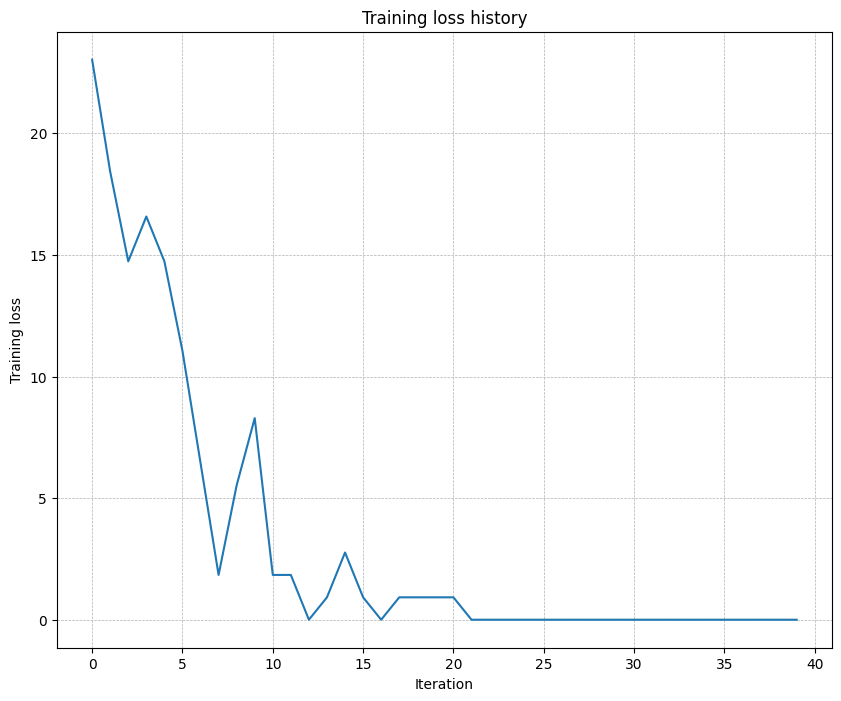

In [ ]:
# TODO: Use a three-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  "X_train": data["X_train"][:num_train],
  "y_train": data["y_train"][:num_train],
  "X_val": data["X_val"],
  "y_val": data["y_val"],
}

weight_scale = 0.5  # Experiment with this!
learning_rate = 2e-4  # Experiment with this!
model = FullyConnectedNet(
    [100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule="sgd",
    optim_config={"learning_rate": learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title("Training loss history")
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

Now, try to use a five-layer network with 100 units on each layer to overfit on 50 training examples. Again, you will have to adjust the learning rate and weight initialization scale, but you should be able to achieve 100% training accuracy within 20 epochs.

(Iteration 1 / 40) loss: 23.025851
(Epoch 0 / 20) train acc: 0.080000; val_acc: 0.089000
(Epoch 1 / 20) train acc: 0.160000; val_acc: 0.079000
(Epoch 2 / 20) train acc: 0.100000; val_acc: 0.101000
(Epoch 3 / 20) train acc: 0.140000; val_acc: 0.105000
(Epoch 4 / 20) train acc: 0.100000; val_acc: 0.105000
(Epoch 5 / 20) train acc: 0.160000; val_acc: 0.112000
(Iteration 11 / 40) loss: 17.499685
(Epoch 6 / 20) train acc: 0.060000; val_acc: 0.100000
(Epoch 7 / 20) train acc: 0.120000; val_acc: 0.120000
(Epoch 8 / 20) train acc: 0.100000; val_acc: 0.101000
(Epoch 9 / 20) train acc: 0.140000; val_acc: 0.102000
(Epoch 10 / 20) train acc: 0.180000; val_acc: 0.104000
(Iteration 21 / 40) loss: 15.950376
(Epoch 11 / 20) train acc: 0.080000; val_acc: 0.087000
(Epoch 12 / 20) train acc: 0.120000; val_acc: 0.105000


/content/drive/My Drive/cs231n/assignments/assignment2/cs231n/classifiers/fc_net.py:236: RuntimeWarning: overflow encountered in square
  W_squared_sum += 0.5 * self.reg * np.sum(self.params[f'W{i}'] ** 2)
/content/drive/My Drive/cs231n/assignments/assignment2/cs231n/classifiers/fc_net.py:236: RuntimeWarning: invalid value encountered in scalar multiply
  W_squared_sum += 0.5 * self.reg * np.sum(self.params[f'W{i}'] ** 2)


(Epoch 13 / 20) train acc: 0.120000; val_acc: 0.119000
(Epoch 14 / 20) train acc: 0.120000; val_acc: 0.119000
(Epoch 15 / 20) train acc: 0.120000; val_acc: 0.119000
(Iteration 31 / 40) loss: nan
(Epoch 16 / 20) train acc: 0.120000; val_acc: 0.119000
(Epoch 17 / 20) train acc: 0.120000; val_acc: 0.119000
(Epoch 18 / 20) train acc: 0.120000; val_acc: 0.119000
(Epoch 19 / 20) train acc: 0.120000; val_acc: 0.119000
(Epoch 20 / 20) train acc: 0.120000; val_acc: 0.119000


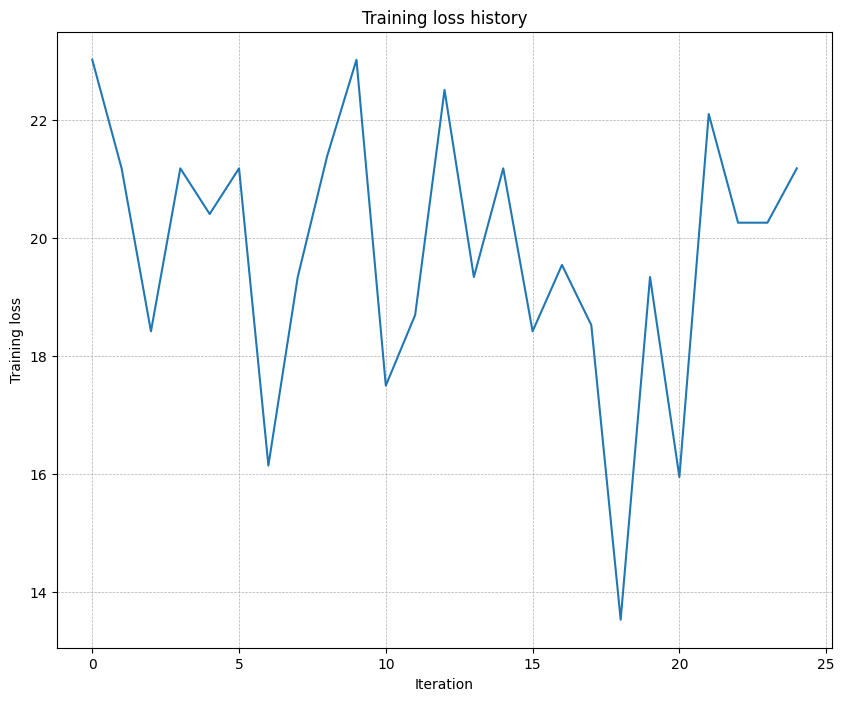

In [ ]:
# TODO: Use a five-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

learning_rate = 2e-3  # Experiment with this!
weight_scale = 0.12   # Experiment with this!
model = FullyConnectedNet(
    [100, 100, 100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule='sgd',
    optim_config={'learning_rate': learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title('Training loss history')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

## Inline Question 1:
Did you notice anything about the comparative difficulty of training the three-layer network vs. training the five-layer network? In particular, based on your experience, which network seemed more sensitive to the initialization scale? Why do you think that is the case?

## Answer:
5층 네트워크가 weight scale에 더 민감한 것 같음. 값을 조금만 바꿔도 loss가 0에 수렴하던 게 수렴하지 않고, 반대로 3층 네트워크는 값을 크게 바꿔도 수렴하거나 loss가 줄긴 한다.


# Update rules
So far we have used vanilla stochastic gradient descent (SGD) as our update rule. More sophisticated update rules can make it easier to train deep networks. We will implement a few of the most commonly used update rules and compare them to vanilla SGD.

## SGD+Momentum
Stochastic gradient descent with momentum is a widely used update rule that tends to make deep networks converge faster than vanilla stochastic gradient descent. See the Momentum Update section at http://cs231n.github.io/neural-networks-3/#sgd for more information.

Open the file `cs231n/optim.py` and read the documentation at the top of the file to make sure you understand the API. Implement the SGD+momentum update rule in the function `sgd_momentum` and run the following to check your implementation. You should see errors less than e-8.

In [ ]:
from cs231n.optim import sgd_momentum

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {"learning_rate": 1e-3, "velocity": v}
next_w, _ = sgd_momentum(w, dw, config=config)

expected_next_w = np.asarray([
  [ 0.1406,      0.20738947,  0.27417895,  0.34096842,  0.40775789],
  [ 0.47454737,  0.54133684,  0.60812632,  0.67491579,  0.74170526],
  [ 0.80849474,  0.87528421,  0.94207368,  1.00886316,  1.07565263],
  [ 1.14244211,  1.20923158,  1.27602105,  1.34281053,  1.4096    ]])
expected_velocity = np.asarray([
  [ 0.5406,      0.55475789,  0.56891579, 0.58307368,  0.59723158],
  [ 0.61138947,  0.62554737,  0.63970526,  0.65386316,  0.66802105],
  [ 0.68217895,  0.69633684,  0.71049474,  0.72465263,  0.73881053],
  [ 0.75296842,  0.76712632,  0.78128421,  0.79544211,  0.8096    ]])

# Should see relative errors around e-8 or less
print("next_w error: ", rel_error(next_w, expected_next_w))
print("velocity error: ", rel_error(expected_velocity, config["velocity"]))

next_w error:  8.882347033505819e-09
velocity error:  4.269287743278663e-09


Once you have done so, run the following to train a six-layer network with both SGD and SGD+momentum. You should see the SGD+momentum update rule converge faster.

Running with  sgd
(Iteration 1 / 1200) loss: 2.559978
(Epoch 0 / 30) train acc: 0.104000; val_acc: 0.107000
(Iteration 11 / 1200) loss: 2.356070
(Iteration 21 / 1200) loss: 2.214091
(Iteration 31 / 1200) loss: 2.205928
(Epoch 1 / 30) train acc: 0.225000; val_acc: 0.193000
(Iteration 41 / 1200) loss: 2.132095
(Iteration 51 / 1200) loss: 2.118950
(Iteration 61 / 1200) loss: 2.116443
(Iteration 71 / 1200) loss: 2.132549
(Epoch 2 / 30) train acc: 0.298000; val_acc: 0.260000
(Iteration 81 / 1200) loss: 1.977227
(Iteration 91 / 1200) loss: 2.007528
(Iteration 101 / 1200) loss: 2.004762
(Iteration 111 / 1200) loss: 1.885342
(Epoch 3 / 30) train acc: 0.343000; val_acc: 0.287000
(Iteration 121 / 1200) loss: 1.891516
(Iteration 131 / 1200) loss: 1.923677
(Iteration 141 / 1200) loss: 1.957744
(Iteration 151 / 1200) loss: 1.966736
(Epoch 4 / 30) train acc: 0.322000; val_acc: 0.305000
(Iteration 161 / 1200) loss: 1.801483
(Iteration 171 / 1200) loss: 1.973780
(Iteration 181 / 1200) loss: 1.666572
(

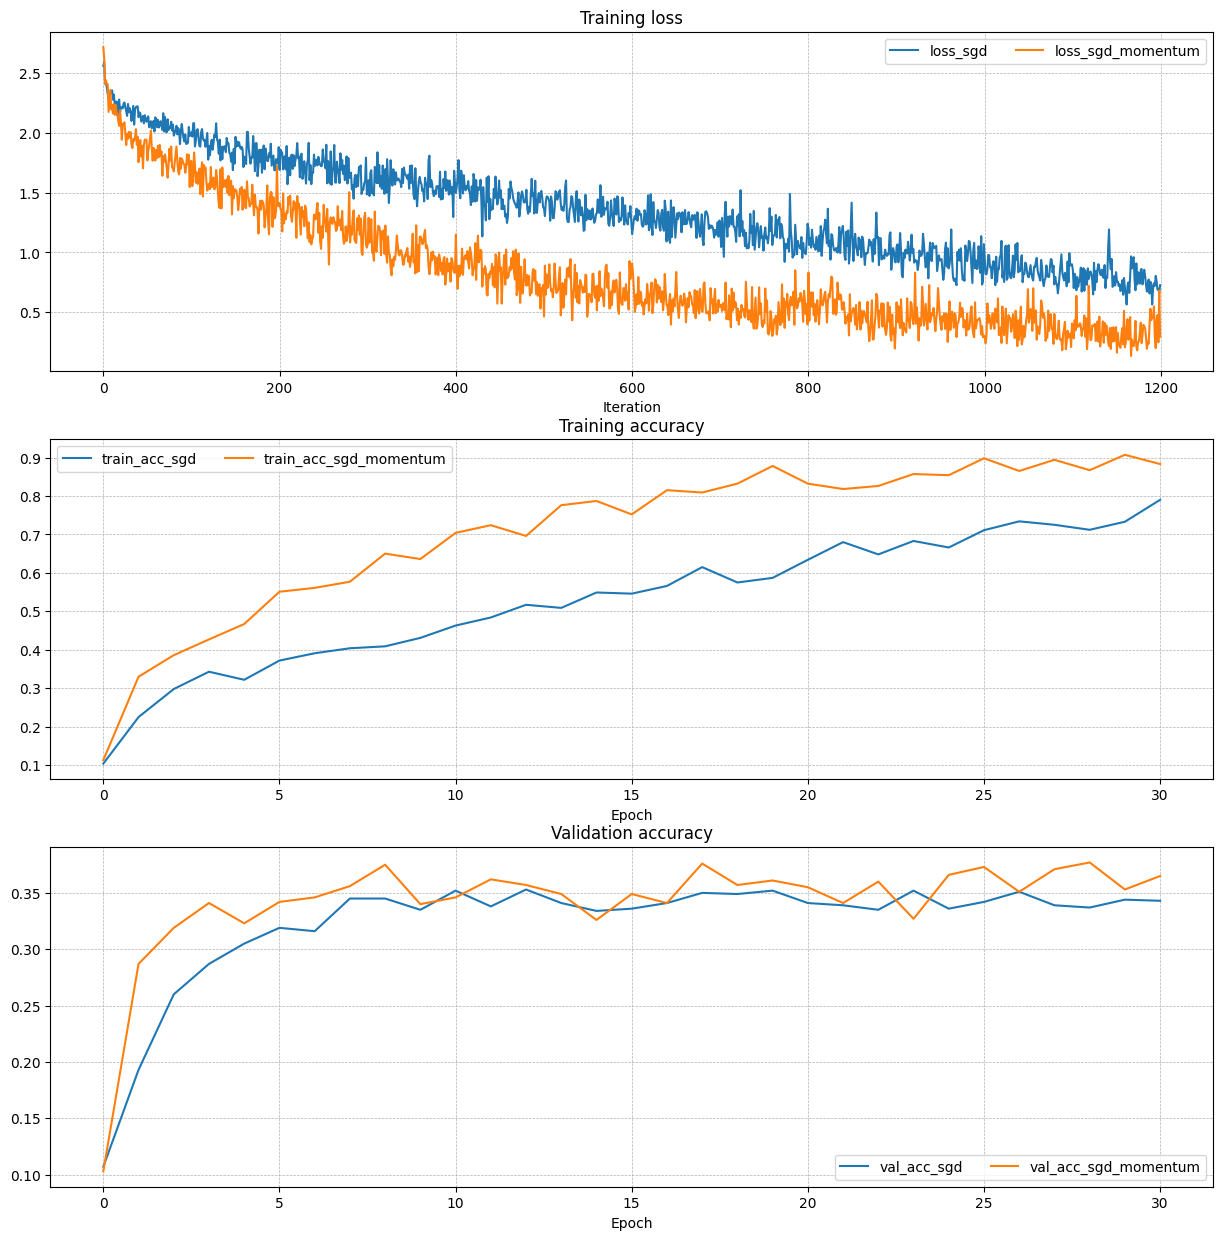

In [ ]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )

    solver = Solver(
        model,
        small_data,
        num_epochs=30,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': 5e-3},
        verbose=True,
    )
    solvers[update_rule] = solver
    solver.train()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"loss_{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"train_acc_{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"val_acc_{update_rule}")

for ax in axes:
    ax.legend(loc="best", ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## RMSProp and Adam
RMSProp [1] and Adam [2] are update rules that set per-parameter learning rates by using a running average of the second moments of gradients.

In the file `cs231n/optim.py`, implement the RMSProp update rule in the `rmsprop` function and implement the Adam update rule in the `adam` function, and check your implementations using the tests below.

**NOTE:** Please implement the _complete_ Adam update rule (with the bias correction mechanism), not the first simplified version mentioned in the course notes.

[1] Tijmen Tieleman and Geoffrey Hinton. "Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude." COURSERA: Neural Networks for Machine Learning 4 (2012).

[2] Diederik Kingma and Jimmy Ba, "Adam: A Method for Stochastic Optimization", ICLR 2015.

In [ ]:
# Test RMSProp implementation
from cs231n.optim import rmsprop

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
  [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
  [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
  [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])
expected_cache = np.asarray([
  [ 0.5976,      0.6126277,   0.6277108,   0.64284931,  0.65804321],
  [ 0.67329252,  0.68859723,  0.70395734,  0.71937285,  0.73484377],
  [ 0.75037008,  0.7659518,   0.78158892,  0.79728144,  0.81302936],
  [ 0.82883269,  0.84469141,  0.86060554,  0.87657507,  0.8926    ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('cache error: ', rel_error(expected_cache, config['cache']))

next_w error:  9.524687511038133e-08
cache error:  2.6477955807156126e-09


In [ ]:
# Test Adam implementation
from cs231n.optim import adam

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
m = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)
v = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
  [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
  [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
  [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
  [ 0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853,],
  [ 0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385,],
  [ 0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767,],
  [ 0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966,   ]])
expected_m = np.asarray([
  [ 0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
  [ 0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
  [ 0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
  [ 0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('v error: ', rel_error(expected_v, config['v']))
print('m error: ', rel_error(expected_m, config['m']))

next_w error:  1.1395691798535431e-07
v error:  4.208314038113071e-09
m error:  4.214963193114416e-09


Once you have debugged your RMSProp and Adam implementations, run the following to train a pair of deep networks using these new update rules:

Running with  adam
(Iteration 1 / 1200) loss: 2.753405
(Epoch 0 / 30) train acc: 0.111000; val_acc: 0.128000
(Iteration 11 / 1200) loss: 2.133217
(Iteration 21 / 1200) loss: 1.880532
(Iteration 31 / 1200) loss: 1.867026
(Epoch 1 / 30) train acc: 0.362000; val_acc: 0.316000
(Iteration 41 / 1200) loss: 1.872760
(Iteration 51 / 1200) loss: 1.738418
(Iteration 61 / 1200) loss: 1.632396
(Iteration 71 / 1200) loss: 1.442968
(Epoch 2 / 30) train acc: 0.420000; val_acc: 0.344000
(Iteration 81 / 1200) loss: 1.627502
(Iteration 91 / 1200) loss: 1.663647
(Iteration 101 / 1200) loss: 1.595734
(Iteration 111 / 1200) loss: 1.460714
(Epoch 3 / 30) train acc: 0.528000; val_acc: 0.354000
(Iteration 121 / 1200) loss: 1.482062
(Iteration 131 / 1200) loss: 1.409466
(Iteration 141 / 1200) loss: 1.343529
(Iteration 151 / 1200) loss: 1.367384
(Epoch 4 / 30) train acc: 0.555000; val_acc: 0.355000
(Iteration 161 / 1200) loss: 1.149550
(Iteration 171 / 1200) loss: 1.235479
(Iteration 181 / 1200) loss: 1.215778


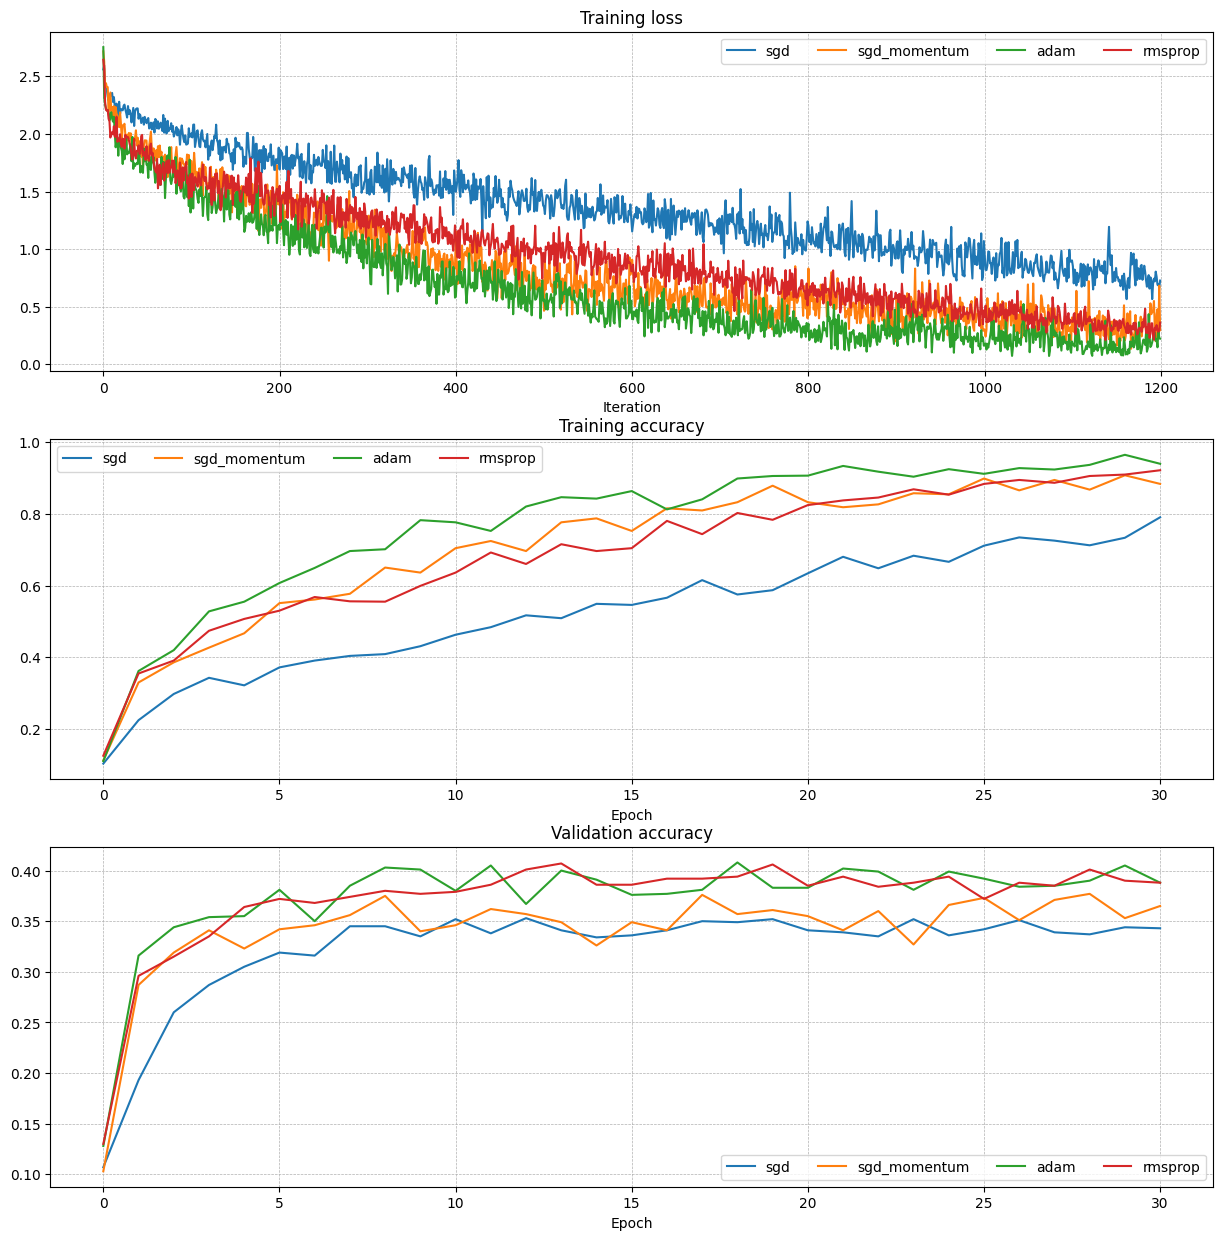

In [ ]:
learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3}
for update_rule in ['adam', 'rmsprop']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )
    solver = Solver(
        model,
        small_data,
        num_epochs=30,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': learning_rates[update_rule]},
        verbose=True
    )
    solvers[update_rule] = solver
    solver.train()
    print()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"{update_rule}")

for ax in axes:
    ax.legend(loc='best', ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## Inline Question 2:

AdaGrad, like Adam, is a per-parameter optimization method that uses the following update rule:

```
cache += dw**2
w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

John notices that when he was training a network with AdaGrad that the updates became very small, and that his network was learning slowly. Using your knowledge of the AdaGrad update rule, why do you think the updates would become very small? Would Adam have the same issue?


## Answer:
dx 제곱을 매 epoch마다 계속해서 더해나가기 때문에 (위 코드에선 `cache`) 업데이트 값은 점점 작아질 수밖에 없음. 이를 개선한 RMSprop, Adam에서는 여기에 decay_rate을 곱하기 때문에 업데이트값이 무한히 작아지는 걸 완화시킴.


# Train a Good Model!
Train the best fully connected model that you can on CIFAR-10, storing your best model in the `best_model` variable. We require you to get at least 50% accuracy on the validation set using a fully connected network.

If you are careful it should be possible to get accuracies above 55%, but we don't require it for this part and won't assign extra credit for doing so. Later in the assignment we will ask you to train the best convolutional network that you can on CIFAR-10, and we would prefer that you spend your effort working on convolutional networks rather than fully connected networks.

**Note:** You might find it useful to complete the `BatchNormalization.ipynb` and `Dropout.ipynb` notebooks before completing this part, since those techniques can help you train powerful models.

lr: 7.4709e-05, reg: 1.4040e+00, hiddendim: [52]


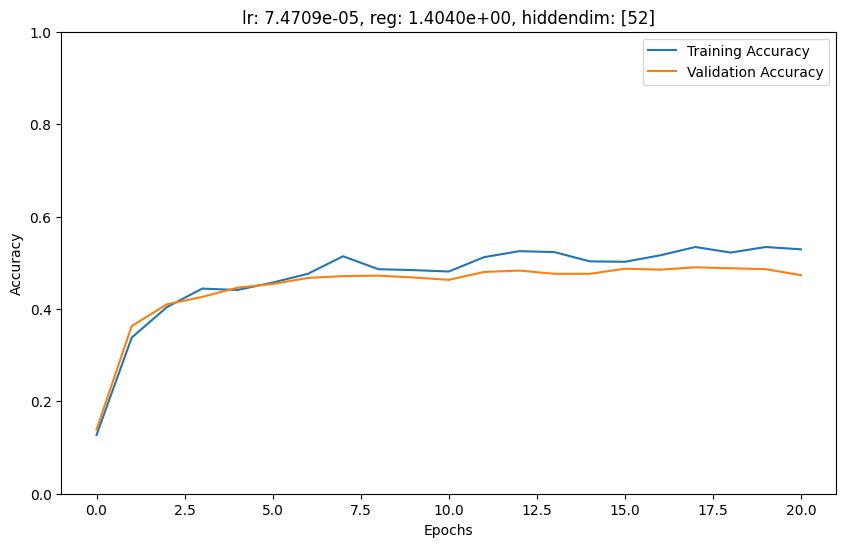

lr: 9.9287e-05, reg: 2.7853e+00, hiddendim: [160]


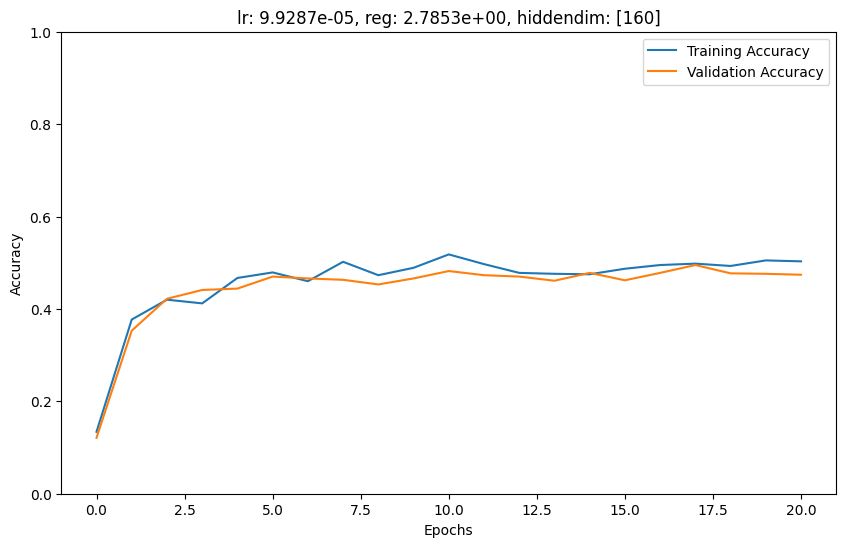

lr: 5.5744e-05, reg: 1.0237e+00, hiddendim: [279]


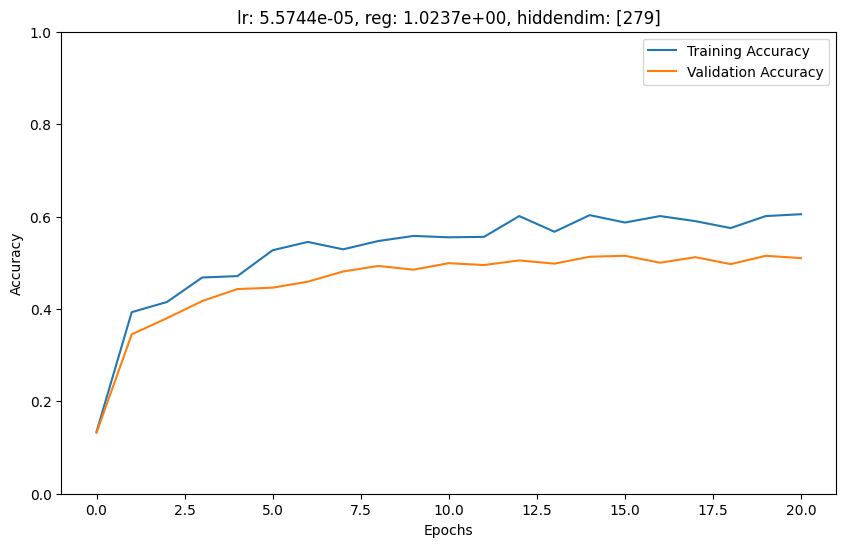

lr: 1.0191e-03, reg: 1.3158e+00, hiddendim: [242]


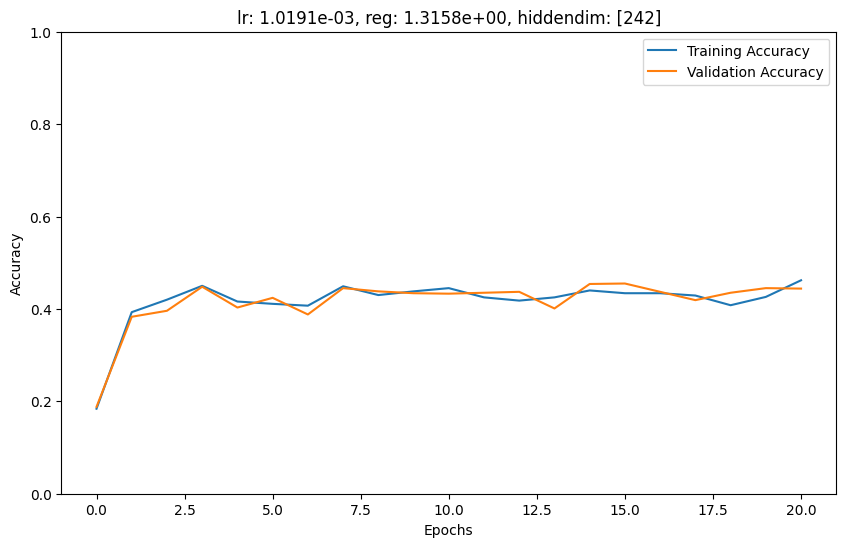

lr: 1.0430e-05, reg: 2.7226e+00, hiddendim: [307]


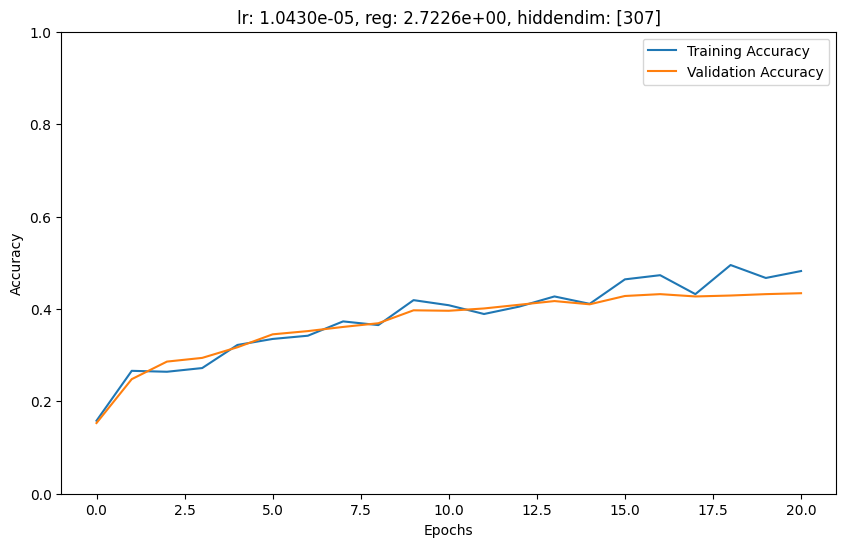

lr: 3.9262e-05, reg: 1.0884e+00, hiddendim: [72]


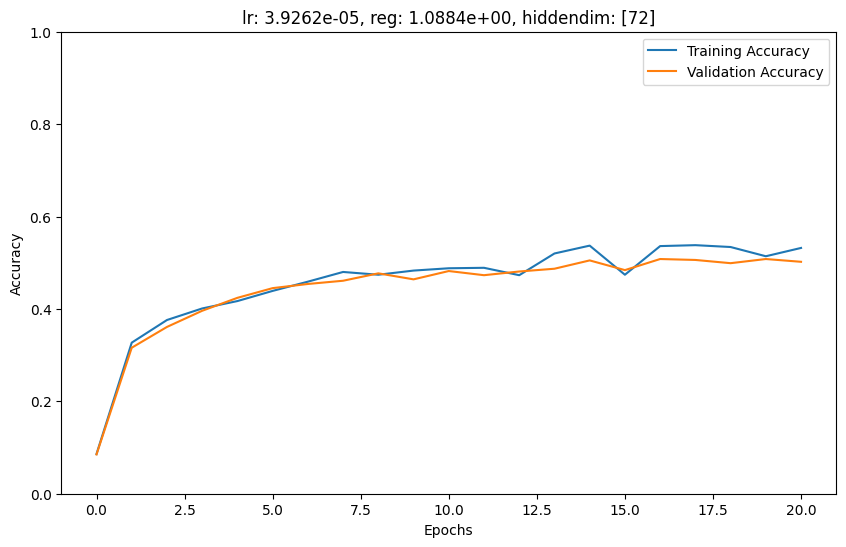

lr: 4.2177e-05, reg: 1.0685e+00, hiddendim: [220]


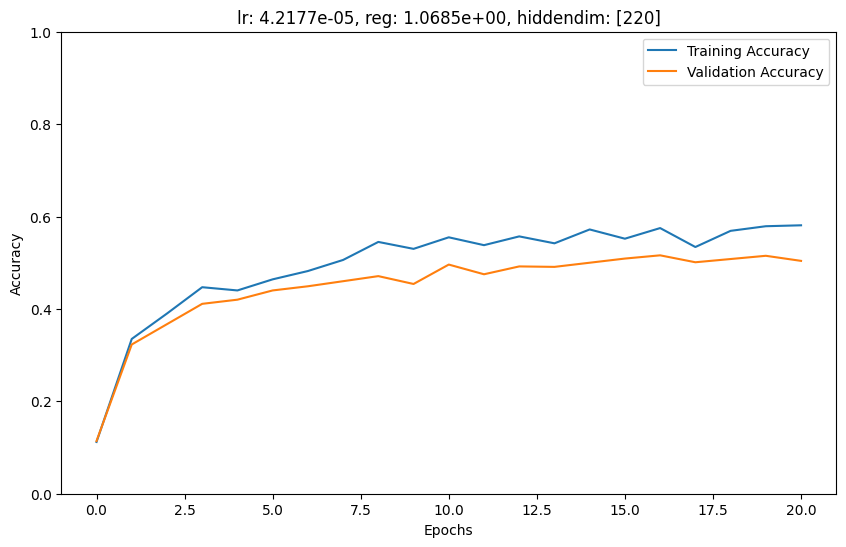

lr: 5.6967e-04, reg: 3.9063e+00, hiddendim: [137]


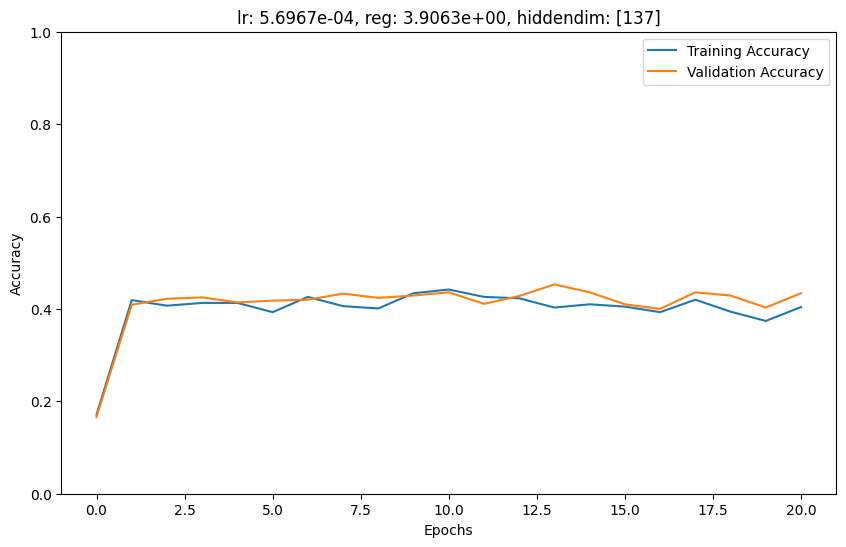

lr: 7.6871e-05, reg: 1.0850e+00, hiddendim: [296]


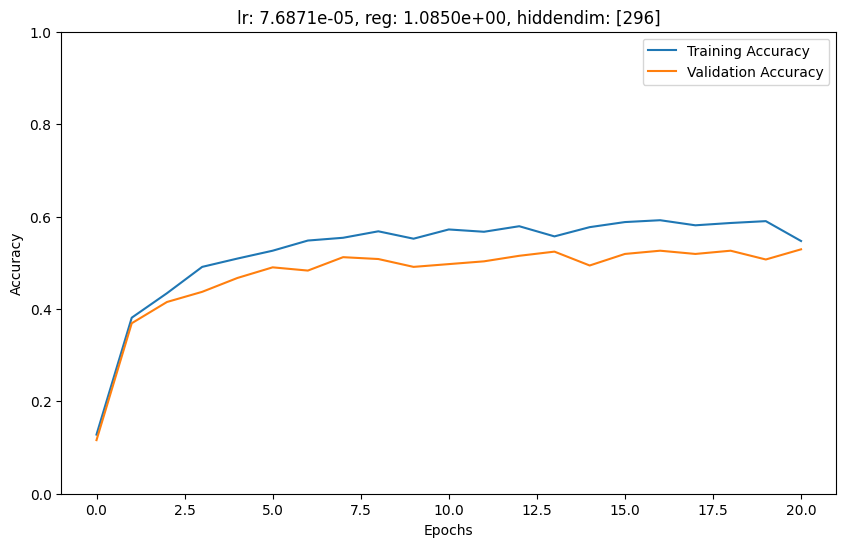

lr: 3.4132e-04, reg: 1.9585e+00, hiddendim: [312]


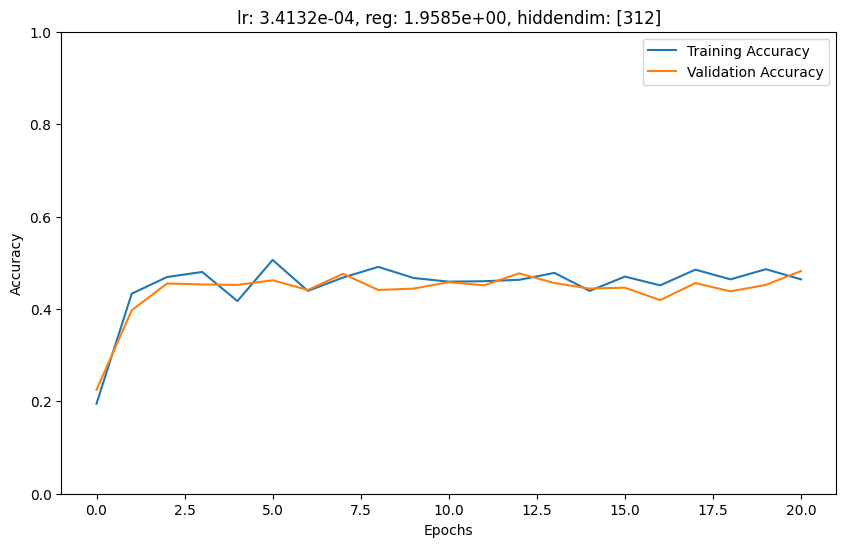

lr: 4.1808e-04, reg: 2.4052e+00, hiddendim: [227]


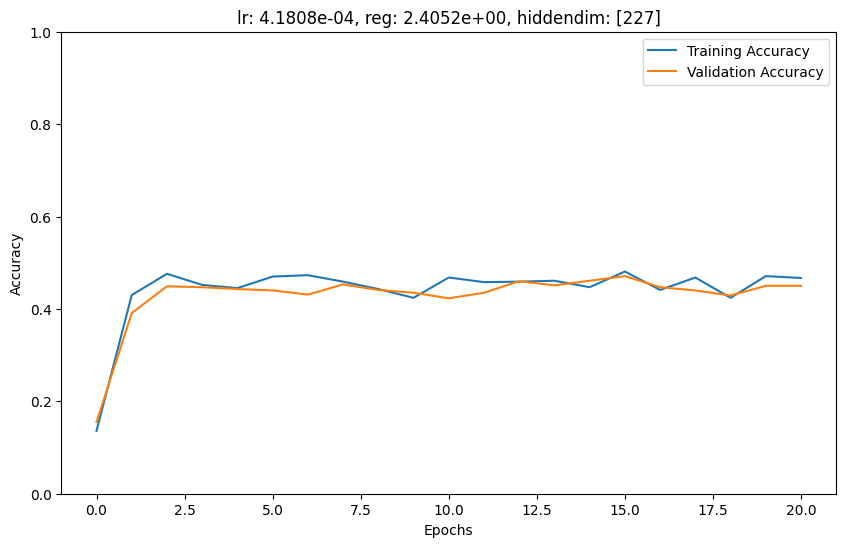

lr: 1.9457e-04, reg: 2.6448e+00, hiddendim: [171]


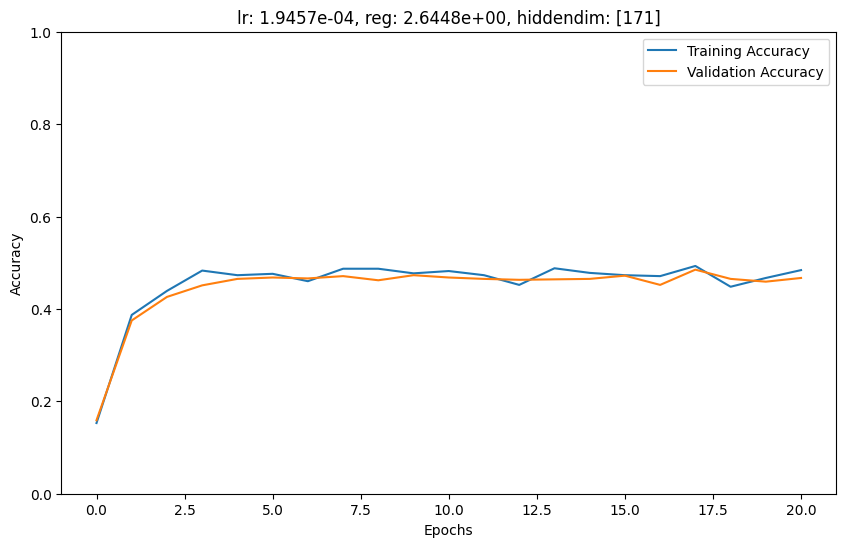

lr: 1.3386e-04, reg: 1.9660e+00, hiddendim: [216]


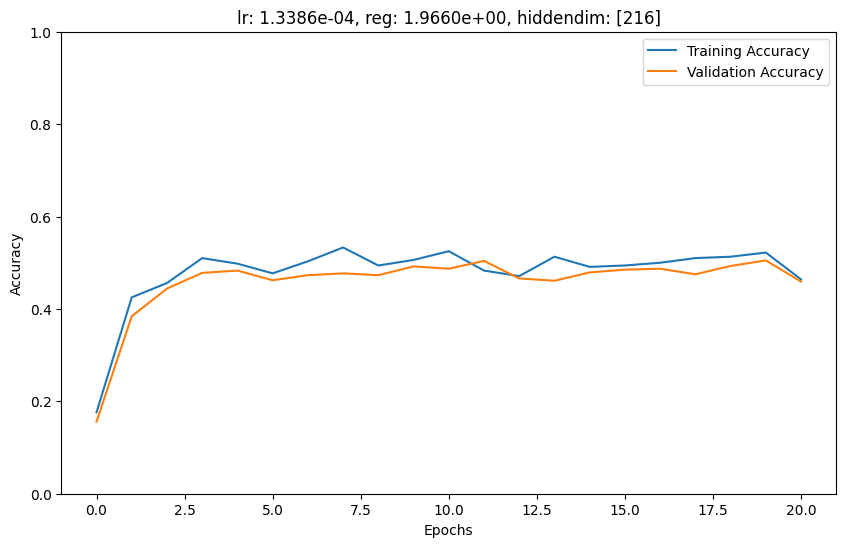

lr: 5.6824e-04, reg: 1.0474e+00, hiddendim: [261]


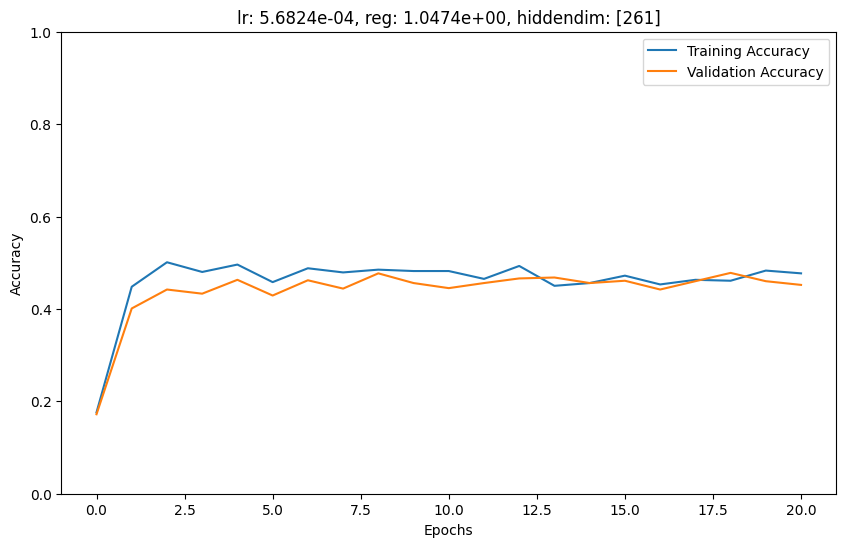

lr: 9.3743e-04, reg: 4.0694e+00, hiddendim: [236]


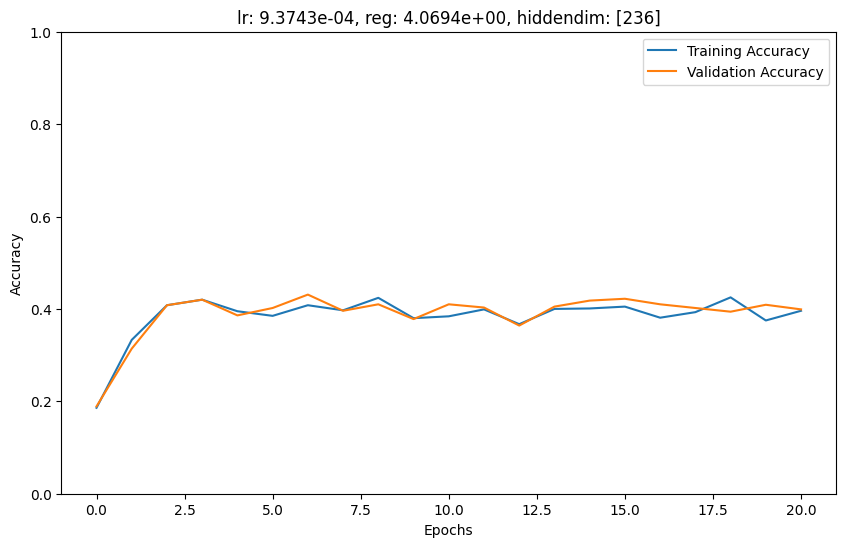

lr: 2.3943e-03, reg: 1.7113e+00, hiddendim: [115]


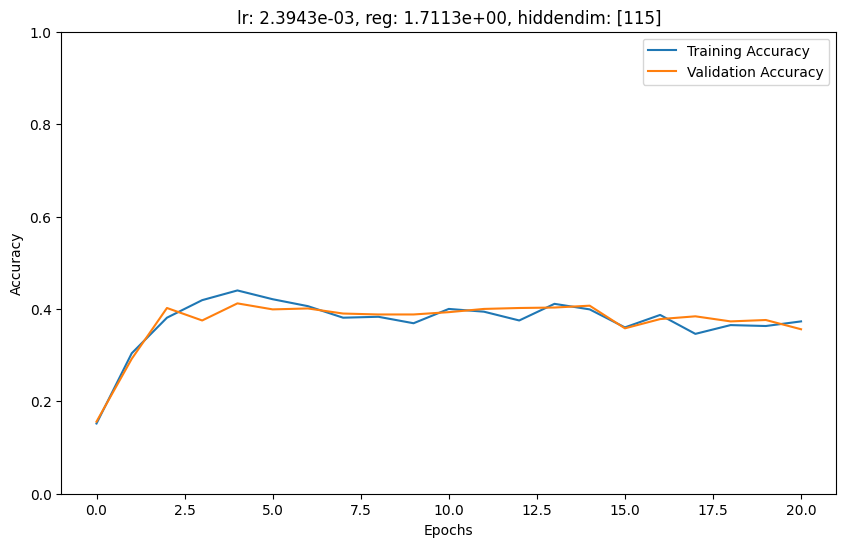

lr: 8.9953e-04, reg: 1.0964e+00, hiddendim: [378]


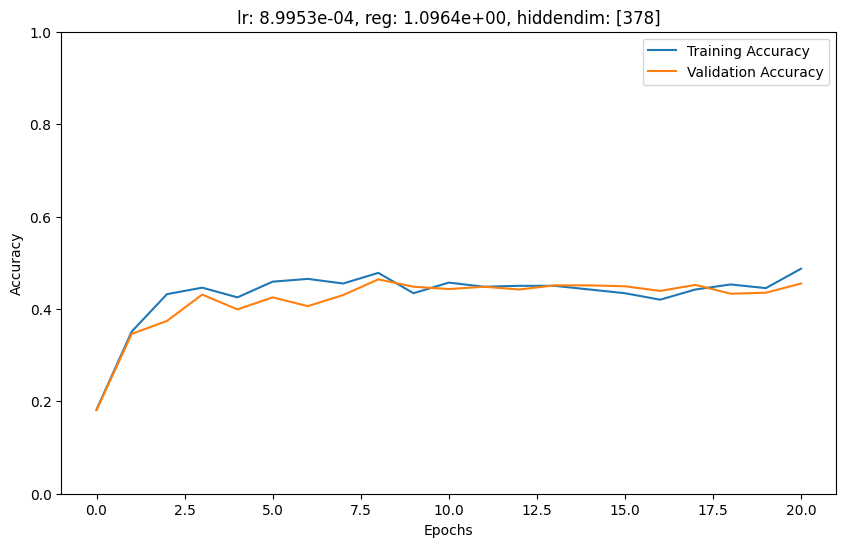

lr: 8.4691e-04, reg: 4.1342e+00, hiddendim: [280]


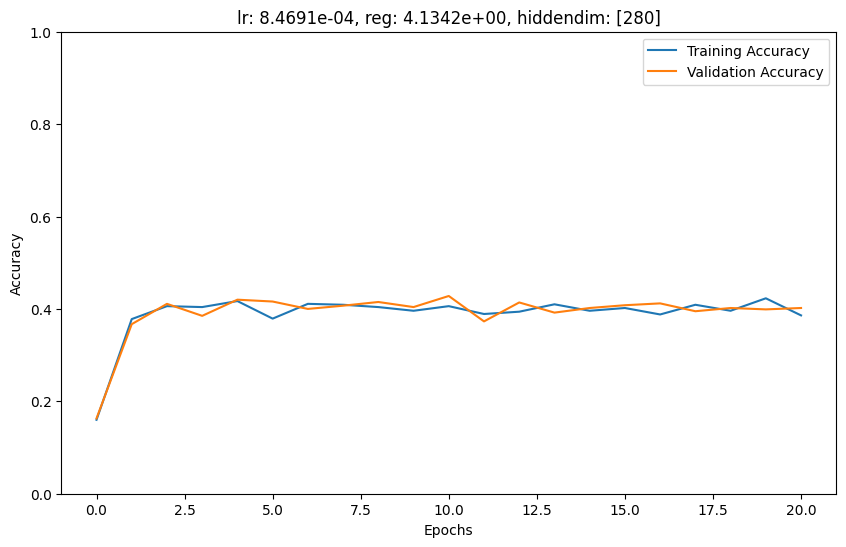

lr: 1.9257e-04, reg: 1.4970e+00, hiddendim: [396]


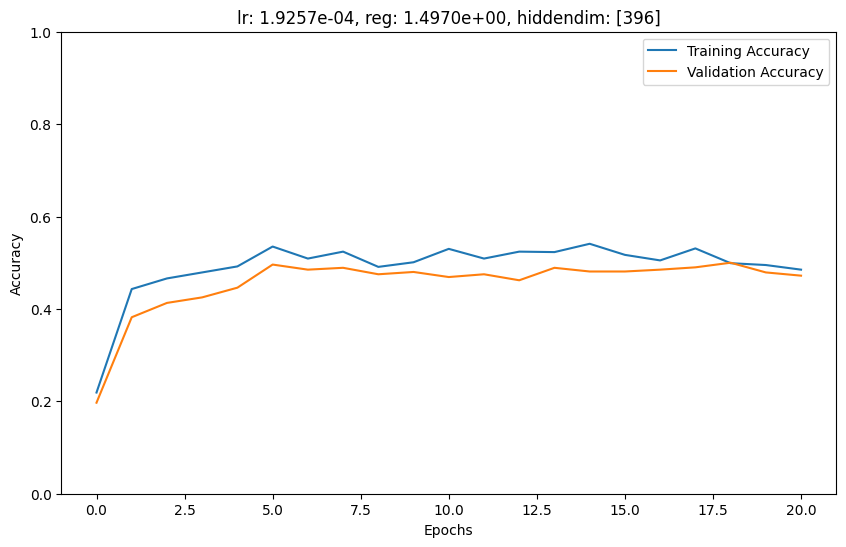

lr: 2.2151e-05, reg: 4.8927e+00, hiddendim: [192]


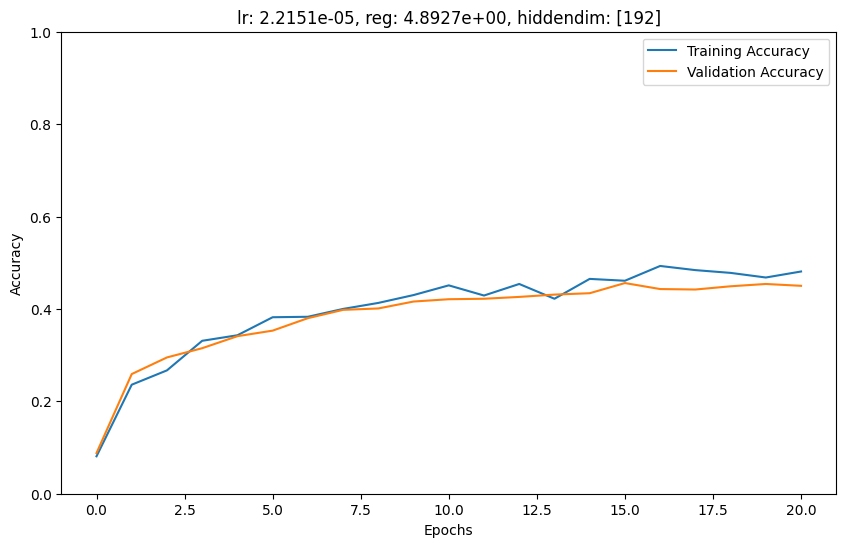

lr: 1.4950e-05, reg: 1.5578e+00, hiddendim: [194]


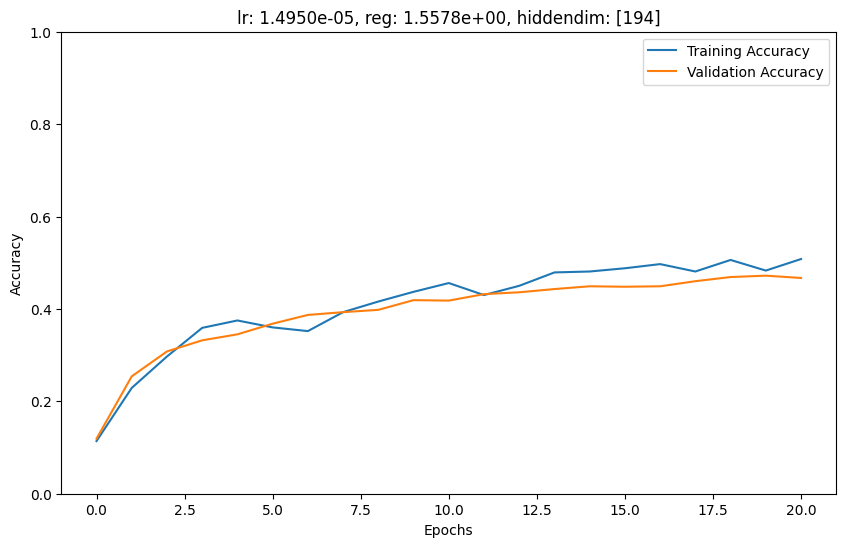

lr: 4.1164e-04, reg: 3.3595e+00, hiddendim: [135]


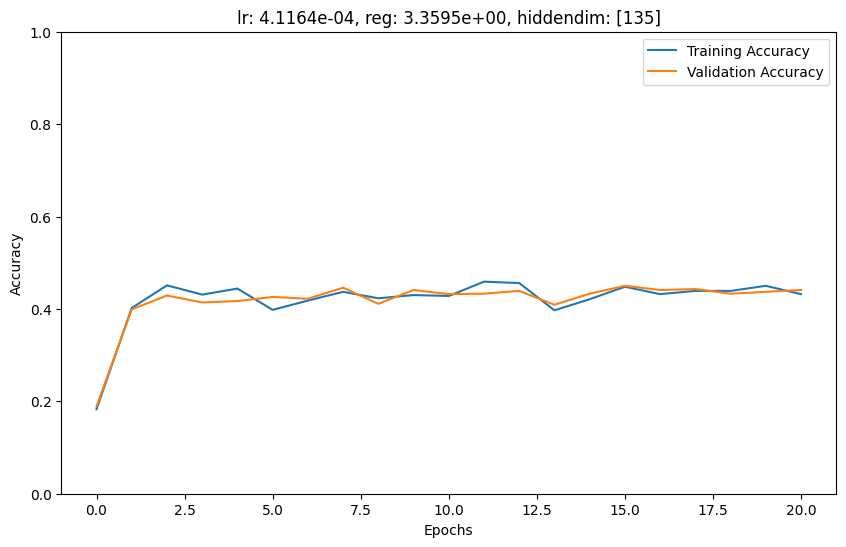

lr: 1.7833e-04, reg: 4.3887e+00, hiddendim: [74]


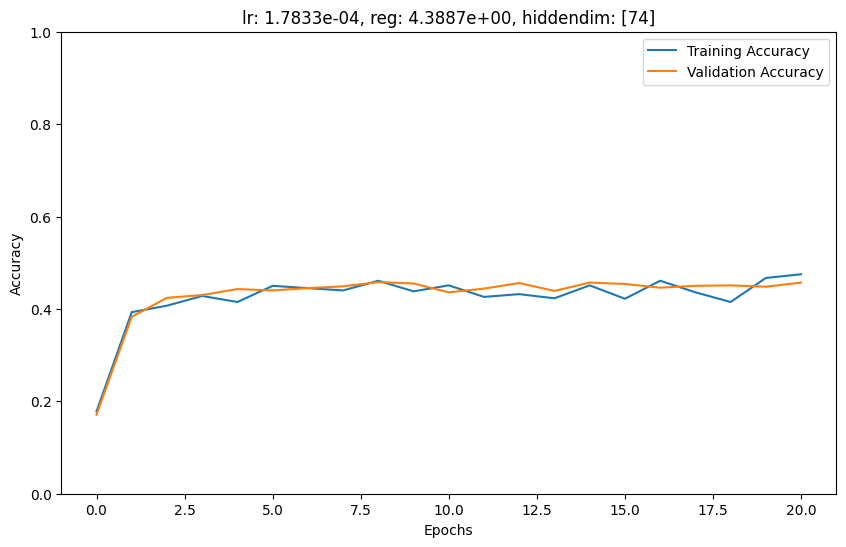

lr: 4.6131e-05, reg: 1.9125e+00, hiddendim: [187]


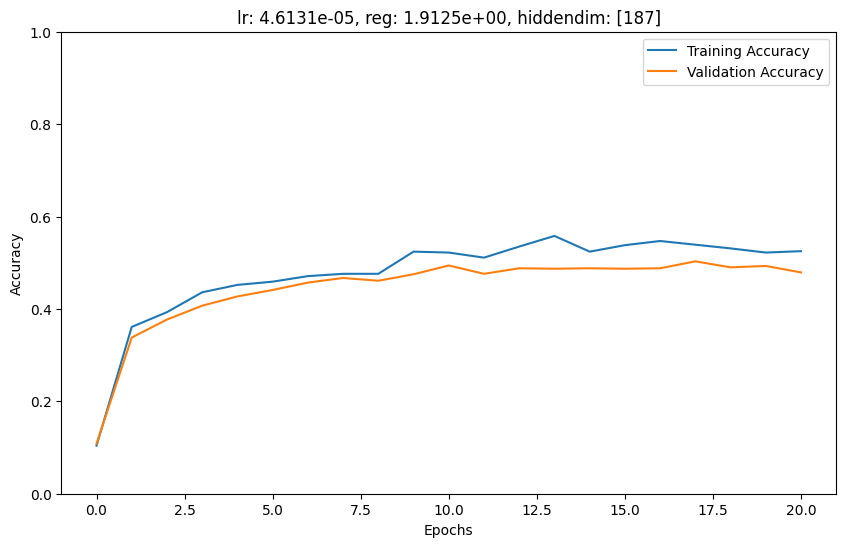

lr: 2.6447e-03, reg: 2.9918e+00, hiddendim: [352]


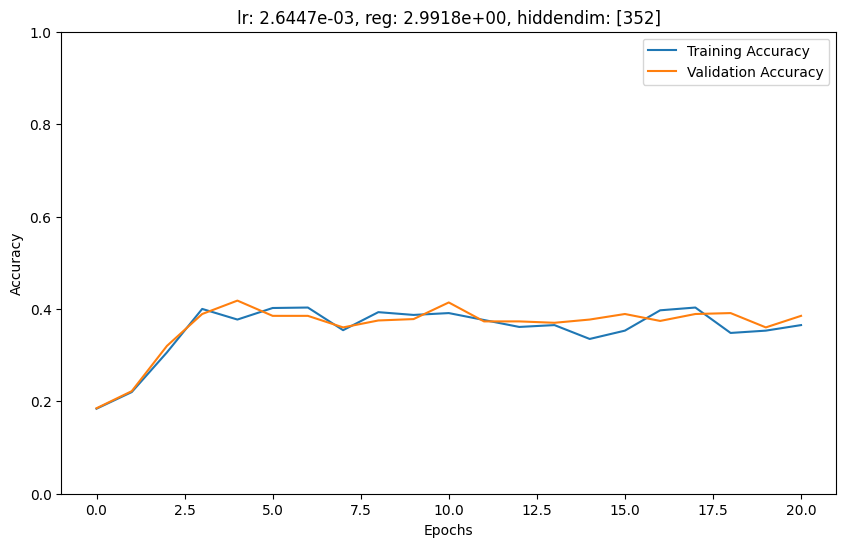

lr: 2.0402e-05, reg: 2.1398e+00, hiddendim: [256]


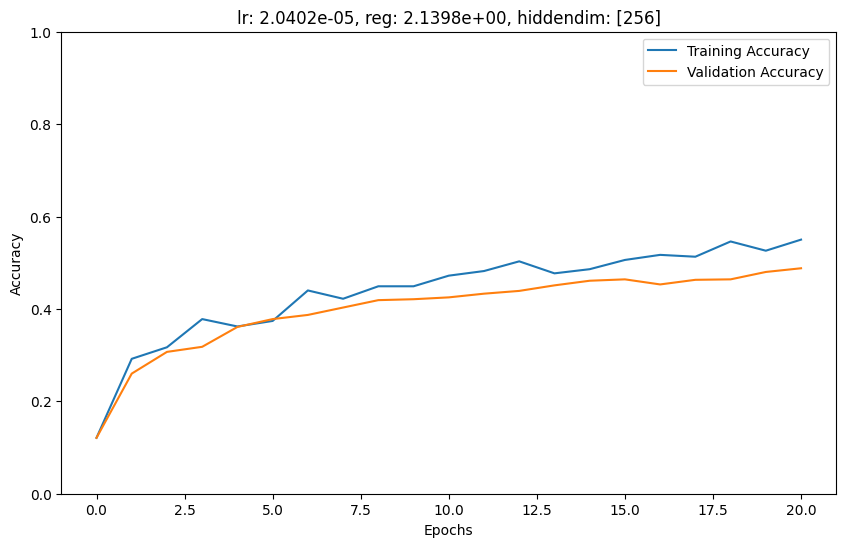

lr: 1.1421e-05, reg: 1.3157e+00, hiddendim: [102]


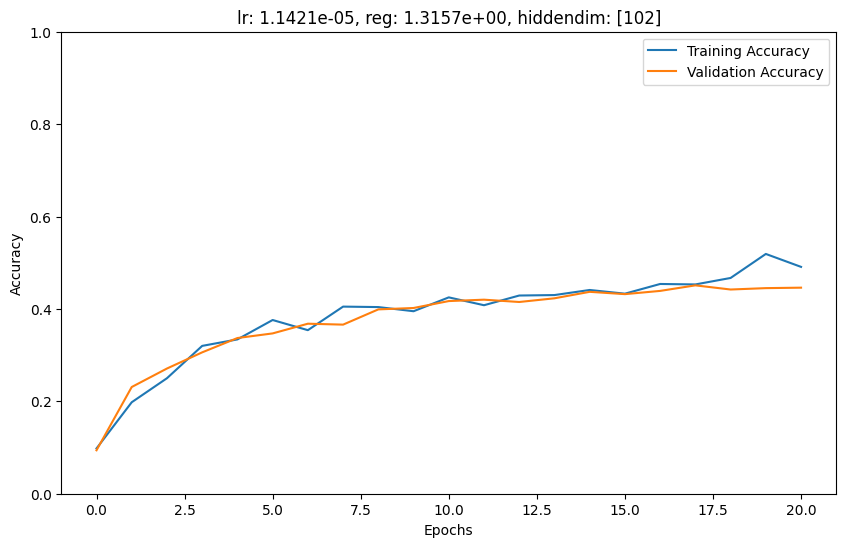

lr: 6.9639e-04, reg: 5.5379e+00, hiddendim: [263]


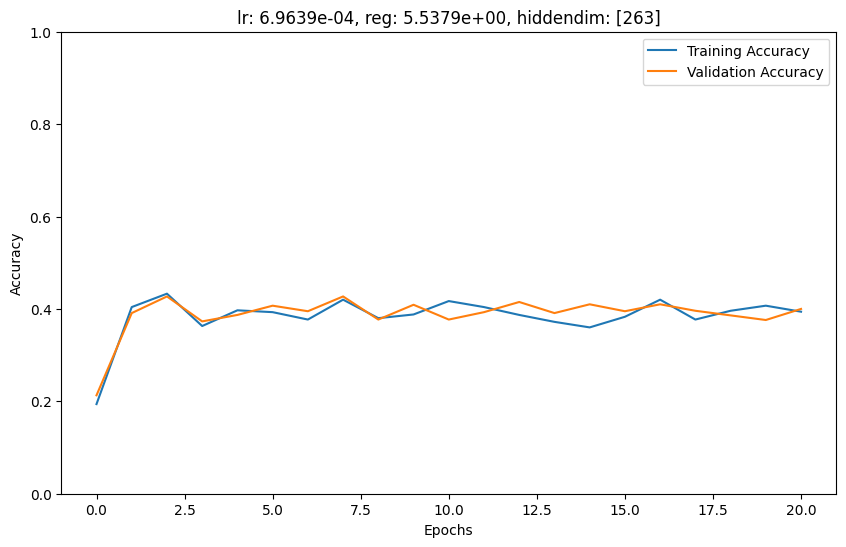

lr: 2.5719e-04, reg: 4.9940e+00, hiddendim: [355]


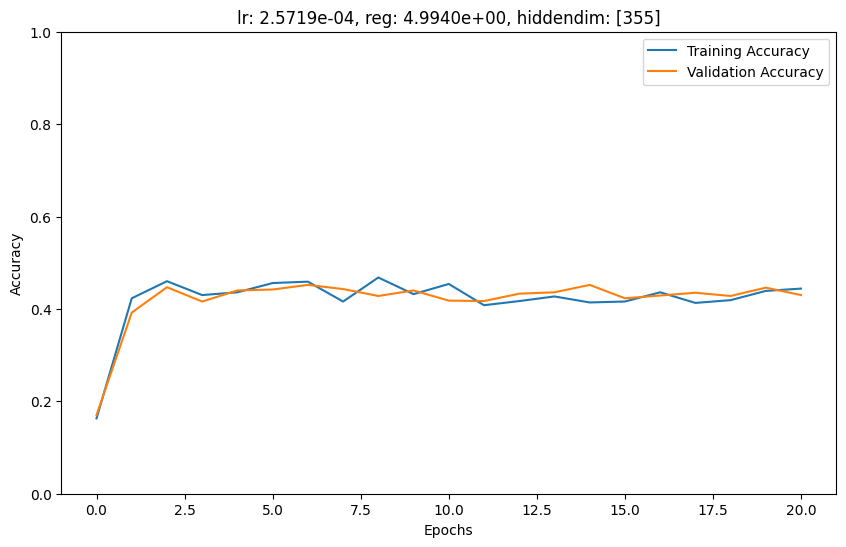

lr: 2.4968e-04, reg: 1.4133e+00, hiddendim: [352]


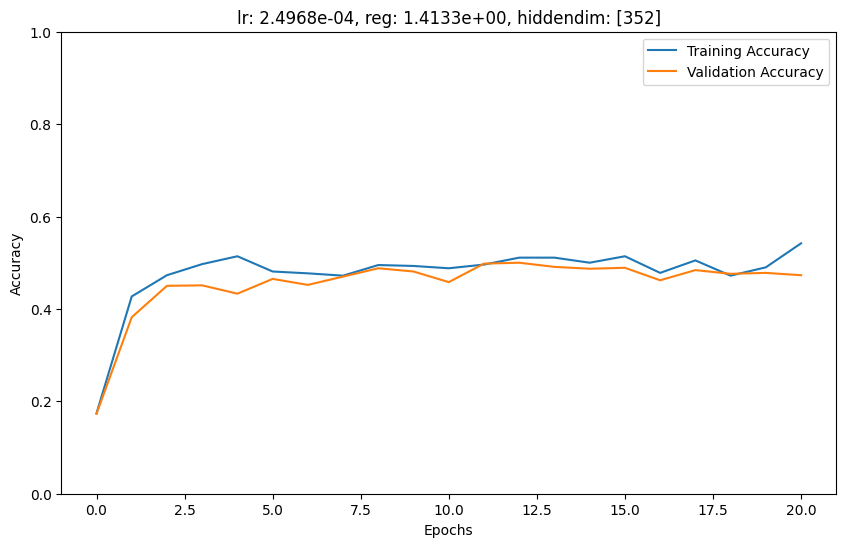

lr 1.043018e-05 hiddendim (307,) reg 2.722634e+00 val acc: 0.434
lr 1.142070e-05 hiddendim (102,) reg 1.315730e+00 val acc: 0.451
lr 1.494995e-05 hiddendim (194,) reg 1.557794e+00 val acc: 0.472
lr 2.040186e-05 hiddendim (256,) reg 2.139831e+00 val acc: 0.488
lr 2.215099e-05 hiddendim (192,) reg 4.892719e+00 val acc: 0.456
lr 3.926182e-05 hiddendim (72,) reg 1.088417e+00 val acc: 0.508
lr 4.217704e-05 hiddendim (220,) reg 1.068503e+00 val acc: 0.516
lr 4.613129e-05 hiddendim (187,) reg 1.912457e+00 val acc: 0.503
lr 5.574395e-05 hiddendim (279,) reg 1.023743e+00 val acc: 0.515
lr 7.470921e-05 hiddendim (52,) reg 1.403976e+00 val acc: 0.49
lr 7.687078e-05 hiddendim (296,) reg 1.085041e+00 val acc: 0.529
lr 9.928673e-05 hiddendim (160,) reg 2.785268e+00 val acc: 0.495
lr 1.338639e-04 hiddendim (216,) reg 1.965967e+00 val acc: 0.505
lr 1.783319e-04 hiddendim (74,) reg 4.388698e+00 val acc: 0.458
lr 1.925673e-04 hiddendim (396,) reg 1.496980e+00 val acc: 0.5
lr 1.945663e-04 hiddendim (171,

In [ ]:
best_model = None

################################################################################
# TODO: Train the best FullyConnectedNet that you can on CIFAR-10. You might   #
# find batch/layer normalization and dropout useful. Store your best model in  #
# the best_model variable.                                                     #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

import time

best_val = -1
results = {}

num_iter = 30

for _ in range(num_iter):

    # set hyperparameters
    lr = 10 ** np.random.uniform(-5, -2.5)
    reg = 10 ** np.random.uniform(0, 0.75)
    hidden_dims = [np.random.randint(50, 400)]
    # 히든 레이어를 두 개 이상 쌓았을 때 학습이 너무 안되서
    # batch-norm, dropout 다 구현하고 다시 시도해보기
    # hidden_dim_size = np.random.randint(1, 3)
    # hidden_dims = [np.random.randint(50, 200) for _ in range(hidden_dim_size)]
    print(f'lr: {lr:.4e}, reg: {reg:.4e}, hiddendim: {hidden_dims}')

    # define model and solver
    model = FullyConnectedNet(
        hidden_dims = hidden_dims,
        reg = reg
    )
    solver = Solver(
        model,
        data,
        update_rule = 'adam',
        optim_config = {
            'learning_rate': lr
        },
        batch_size = 1024,
        num_epochs = 20,
        verbose = False
    )

    # train
    solver.train()
    results[(lr, reg, tuple(hidden_dims))] = solver.best_val_acc
    if solver.best_val_acc > best_val:
        best_val = solver.best_val_acc
        best_model = model

    # visualize
    plt.figure(figsize=(10, 6))
    plt.plot(solver.train_acc_history, label='Training Accuracy')
    plt.plot(solver.val_acc_history, label='Validation Accuracy')
    plt.title(f'lr: {lr:.4e}, reg: {reg:.4e}, hiddendim: {hidden_dims}')
    plt.ylim(0, 1)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

for lr, reg, hidden_dims in sorted(results):
    val_accuracy = results[(lr, reg, hidden_dims)]
    print(f'lr {lr:e} hiddendim {hidden_dims} reg {reg:e} val acc: {val_accuracy}')

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
################################################################################
#                              END OF YOUR CODE                                #
################################################################################

In [ ]:
lr = []
reg = []
dim = []
val_acc = []

for k, v in results.items():
    a, b, c = k
    lr.append(np.log10(a))
    reg.append(np.log10(b))
    dim.append(c[0])
    val_acc.append(v)

In [ ]:
print(lr, reg, dim, val_acc, sep = '\n')

[-4.126625849250462, -4.003108796219214, -4.253802231819447, -2.9917743471960483, -4.981708046166958, -4.40602958654286, -4.3749239061612615, -3.2443803374344427, -4.114238720965304, -3.466840305294851, -3.378738450885848, -3.7109324012693277, -3.873336500100304, -3.2454672319613653, -3.0280613320037606, -2.620813307680831, -3.0459826665153216, -3.072162155588529, -3.7154175088859156, -4.654606876454166, -4.825360307385188, -3.3854794598415037, -3.7487708737791303, -4.336004385802914, -2.577627859203955, -4.690330283906905, -4.942307333780514, -3.157147122517827, -3.5897405369297655, -3.6026140430439133]
[0.1473596268889185, 0.44486695021011324, 0.01019078234596561, 0.11920460432655847, 0.4349892848773368, 0.03679537793956749, 0.028775867453353202, 0.5917612111762636, 0.03544620026090696, 0.2919146520743159, 0.3811599162528486, 0.4223876732480778, 0.2935761977202096, 0.0201140387289974, 0.6095257317264784, 0.23331707224147488, 0.03997347153144404, 0.6163909553229336, 0.1752159604241475

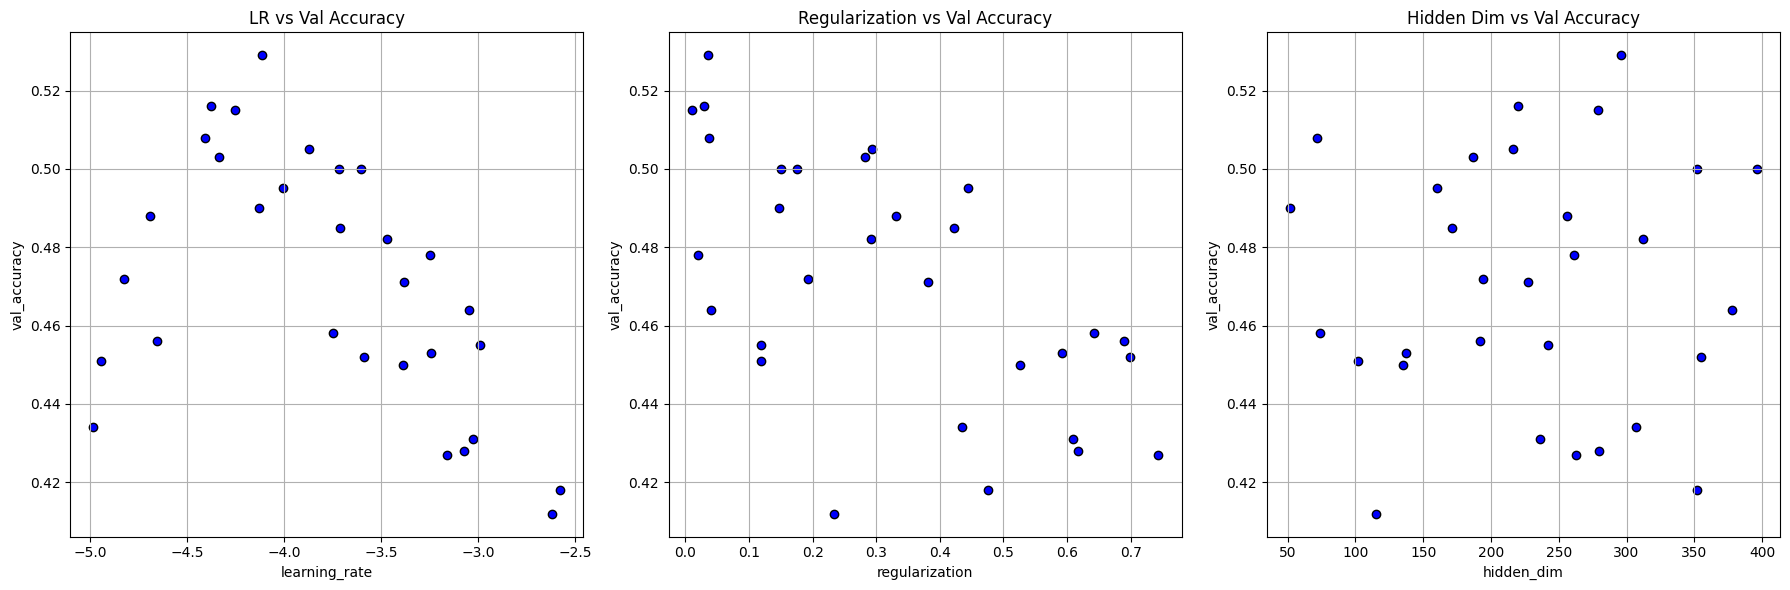

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Scatter plot for learning rate vs validation accuracy
axs[0].scatter(lr, val_acc, color='blue', edgecolor='k')
axs[0].set_title('LR vs Val Accuracy')
axs[0].set_xlabel('learning_rate')
axs[0].set_ylabel('val_accuracy')
axs[0].grid(True)

# Scatter plot for regularization vs validation accuracy
axs[1].scatter(reg, val_acc, color='blue', edgecolor='k')
axs[1].set_title('Regularization vs Val Accuracy')
axs[1].set_xlabel('regularization')
axs[1].set_ylabel('val_accuracy')
axs[1].grid(True)

# Scatter plot for hidden dimensions vs validation accuracy
axs[2].scatter(dim, val_acc, color='blue', edgecolor='k')
axs[2].set_title('Hidden Dim vs Val Accuracy')
axs[2].set_xlabel('hidden_dim')
axs[2].set_ylabel('val_accuracy')
axs[2].grid(True)

plt.tight_layout()
plt.show()

# Test Your Model!
Run your best model on the validation and test sets. You should achieve at least 50% accuracy on the validation set.

In [ ]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())

Validation set accuracy:  0.529
Test set accuracy:  0.514


# Visualizing Input distribution
지금 코드는 잘못된 코드임. 한 노드에 입력되는 전체 minibatch의 입력들에 대해 평균과 분산을 계산해야 되는데, 아래 코드는 한 레이어의 모든 입력에 대해 평균과 분산을 계산하고 있음. 나중에 수정하기

lr: 4.8172e-05, reg: 1.1899e+00, hiddendim: [100, 100, 100]
w1 std: 351.4948842016066, w1 mean: 58.18026778519864
w2 std: 412.8262332503478, w2 mean: -39.99211951250297
w3 std: 339.23320674686835, w3 mean: -63.59923622776718


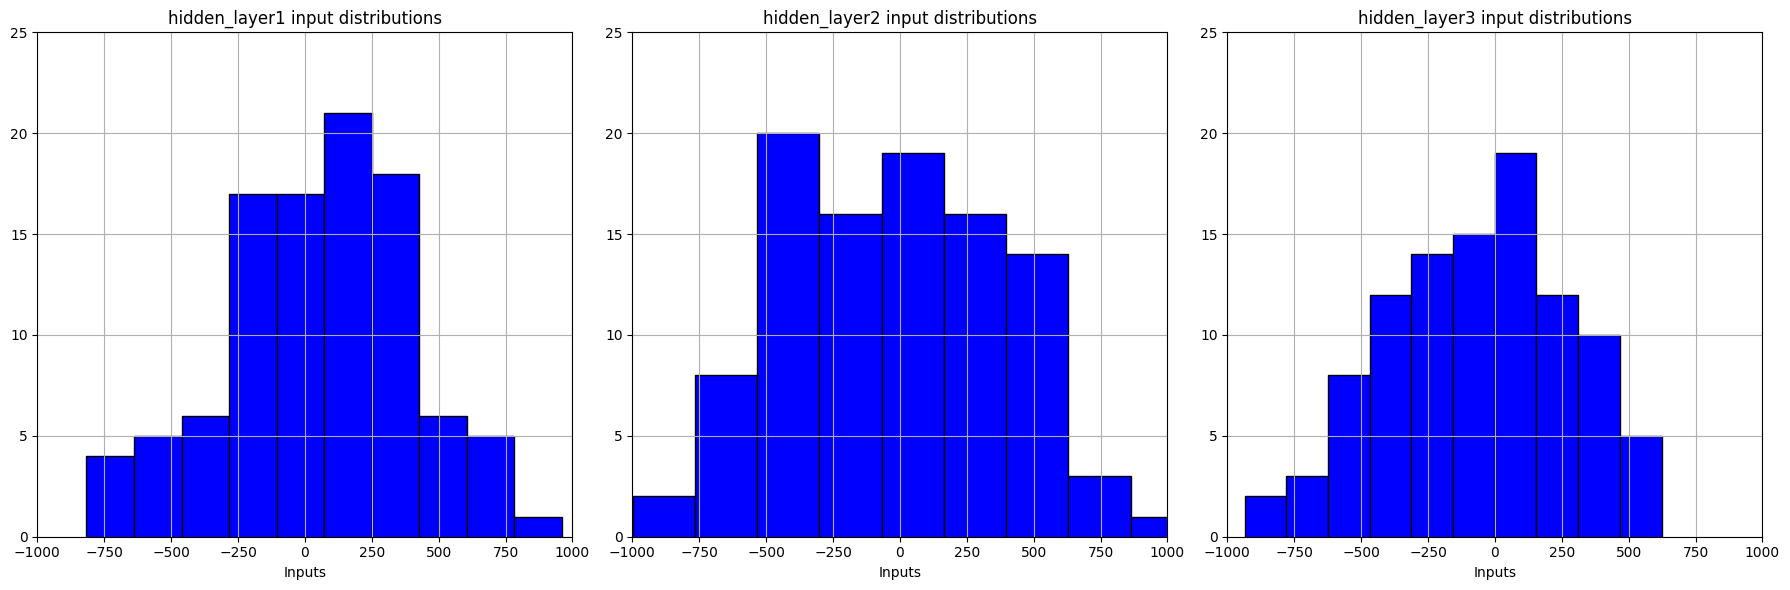

w1 std: 342.8033128884765, w1 mean: 64.15273764445605
w2 std: 408.031683751452, w2 mean: -46.081480885935825
w3 std: 328.04722912062425, w3 mean: -78.44480488684334


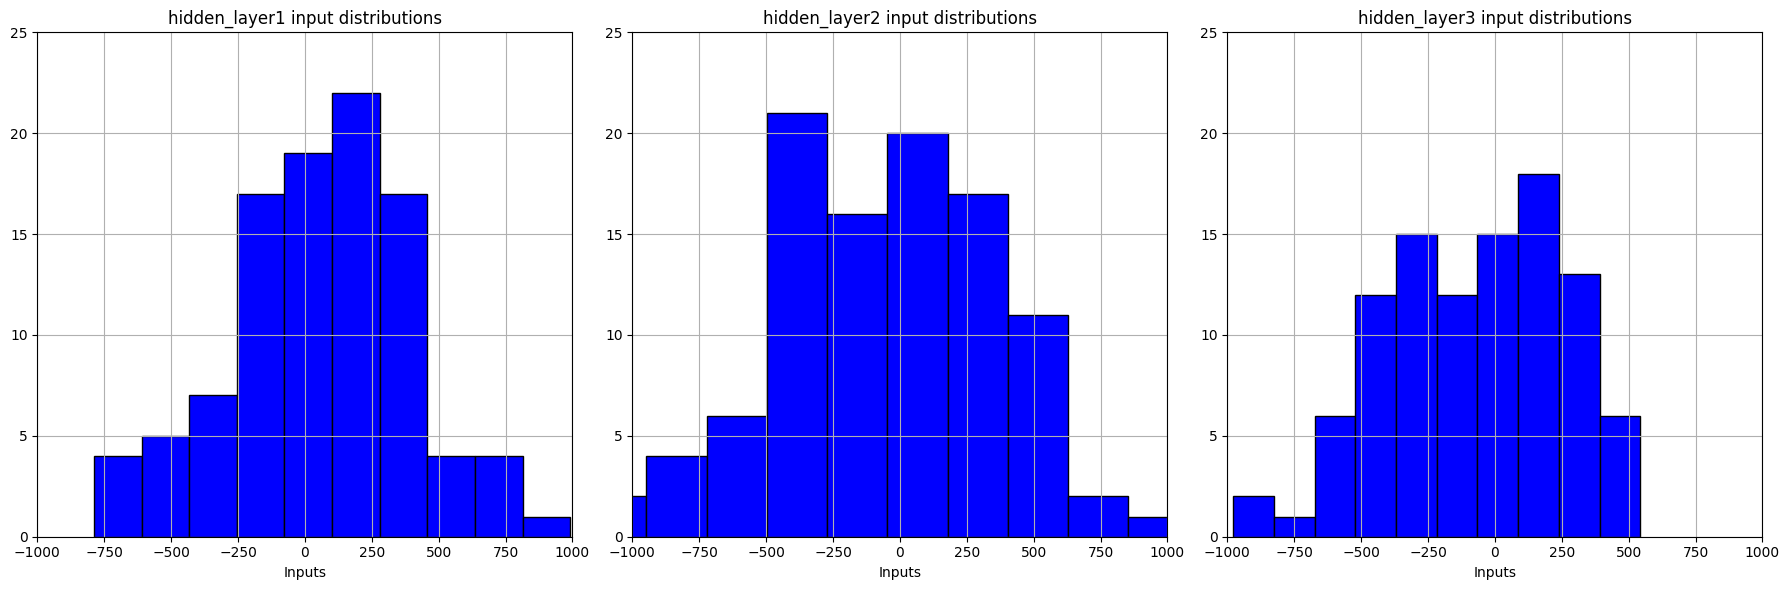

w1 std: 338.15869496097037, w1 mean: 66.93322976654333
w2 std: 407.82980323699906, w2 mean: -51.52059522775215
w3 std: 319.7852407242097, w3 mean: -90.78226330703312


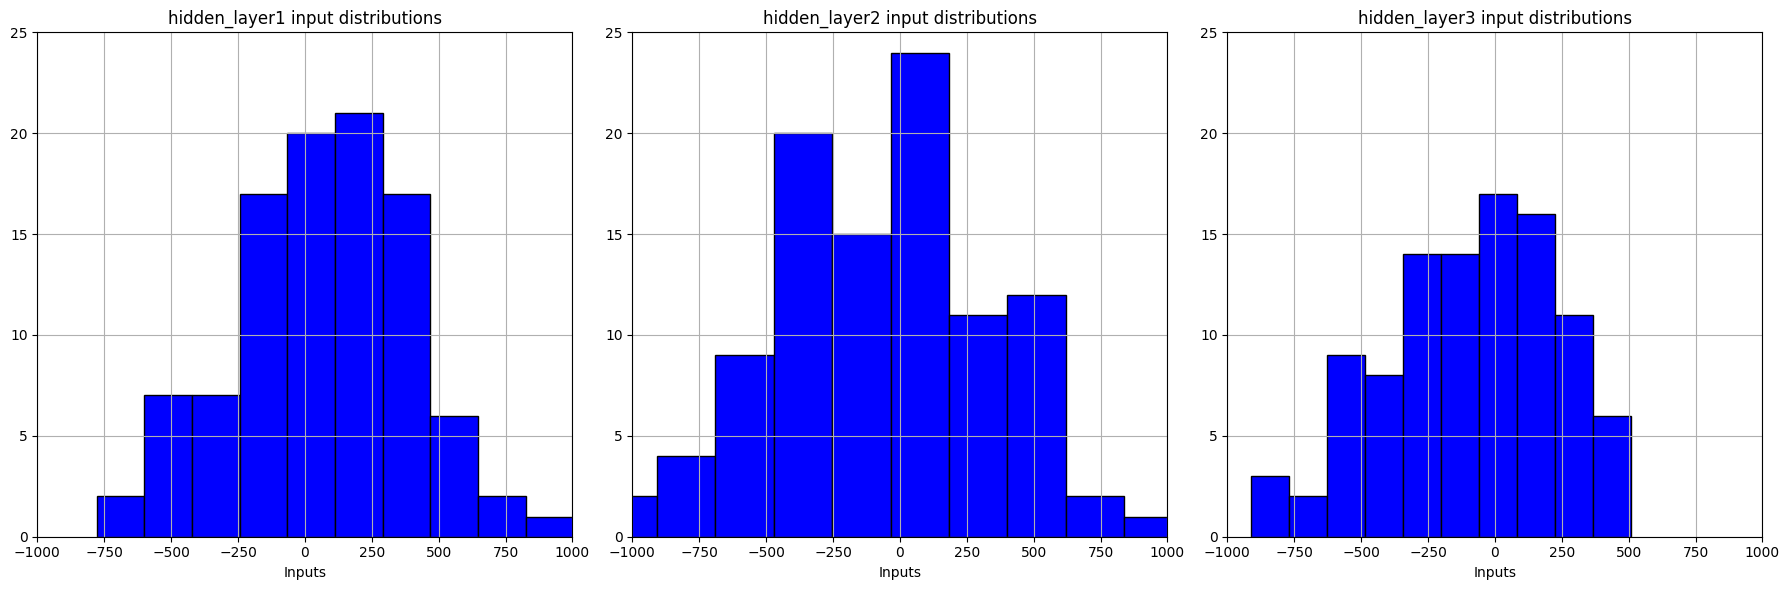

w1 std: 333.37267775472213, w1 mean: 68.58488405958936
w2 std: 403.7346132329939, w2 mean: -56.02631248193272
w3 std: 309.98557284521945, w3 mean: -101.03066466987585


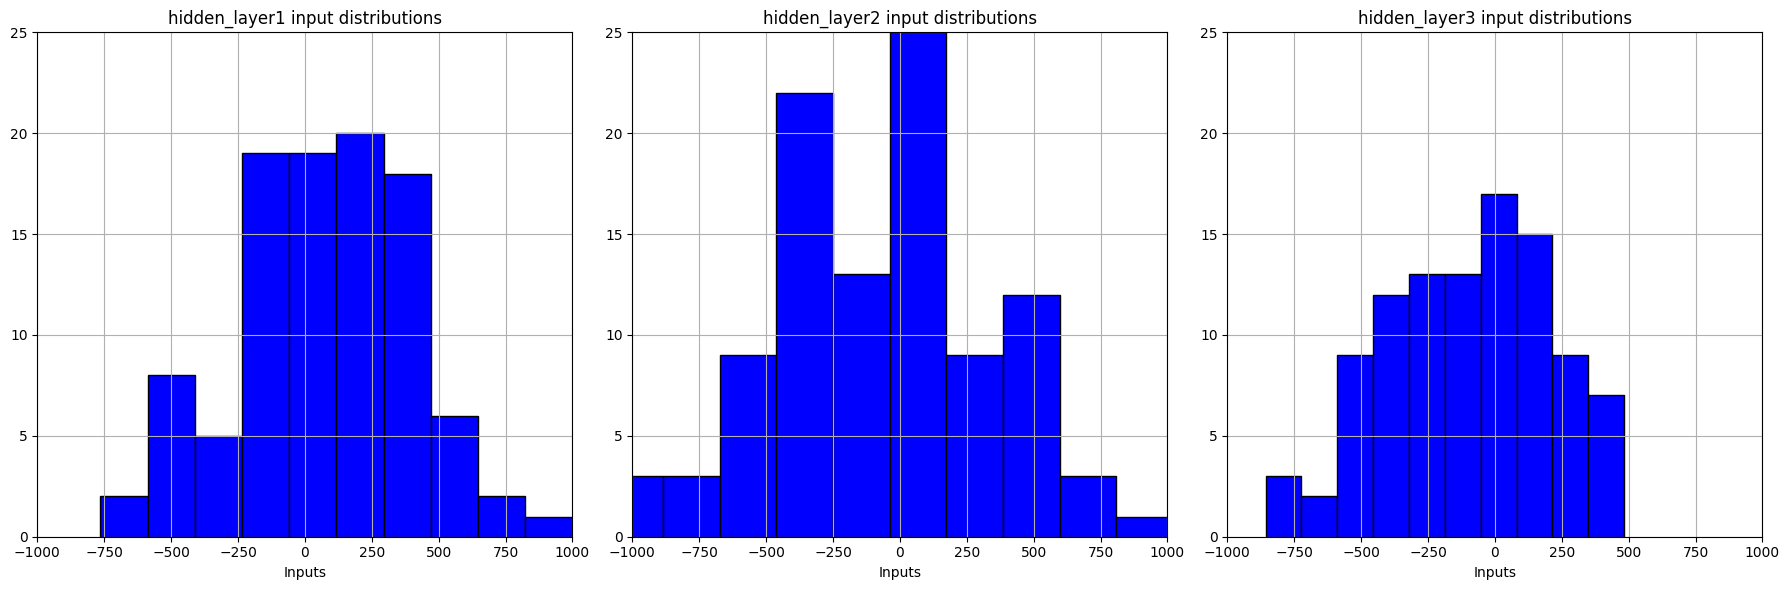

w1 std: 328.8728525232871, w1 mean: 70.30620515657841
w2 std: 398.92994070022667, w2 mean: -62.924197140038686
w3 std: 297.4710443981536, w3 mean: -106.84197780186304


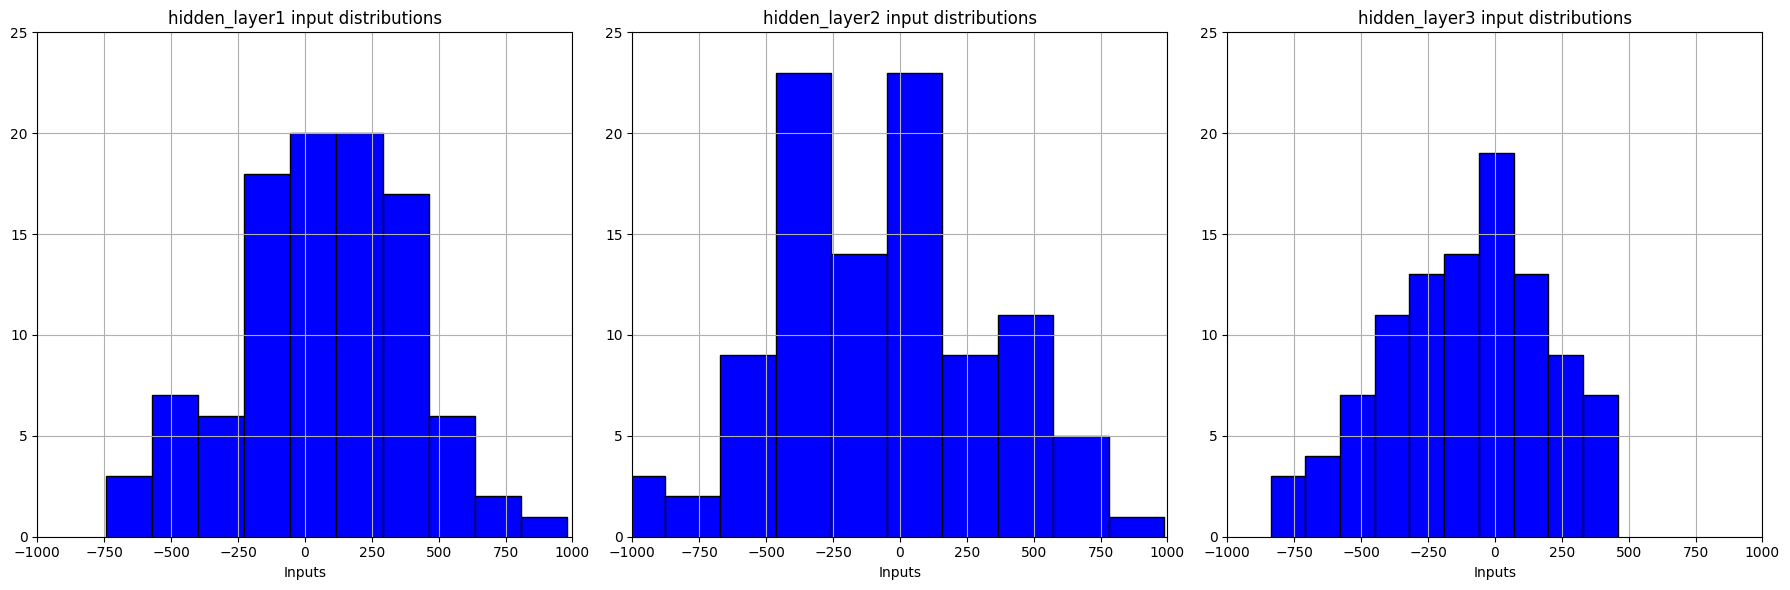

w1 std: 323.37846895927765, w1 mean: 71.80675777123112
w2 std: 394.824622395853, w2 mean: -68.37904065923567
w3 std: 288.10126416979193, w3 mean: -111.06636897428513


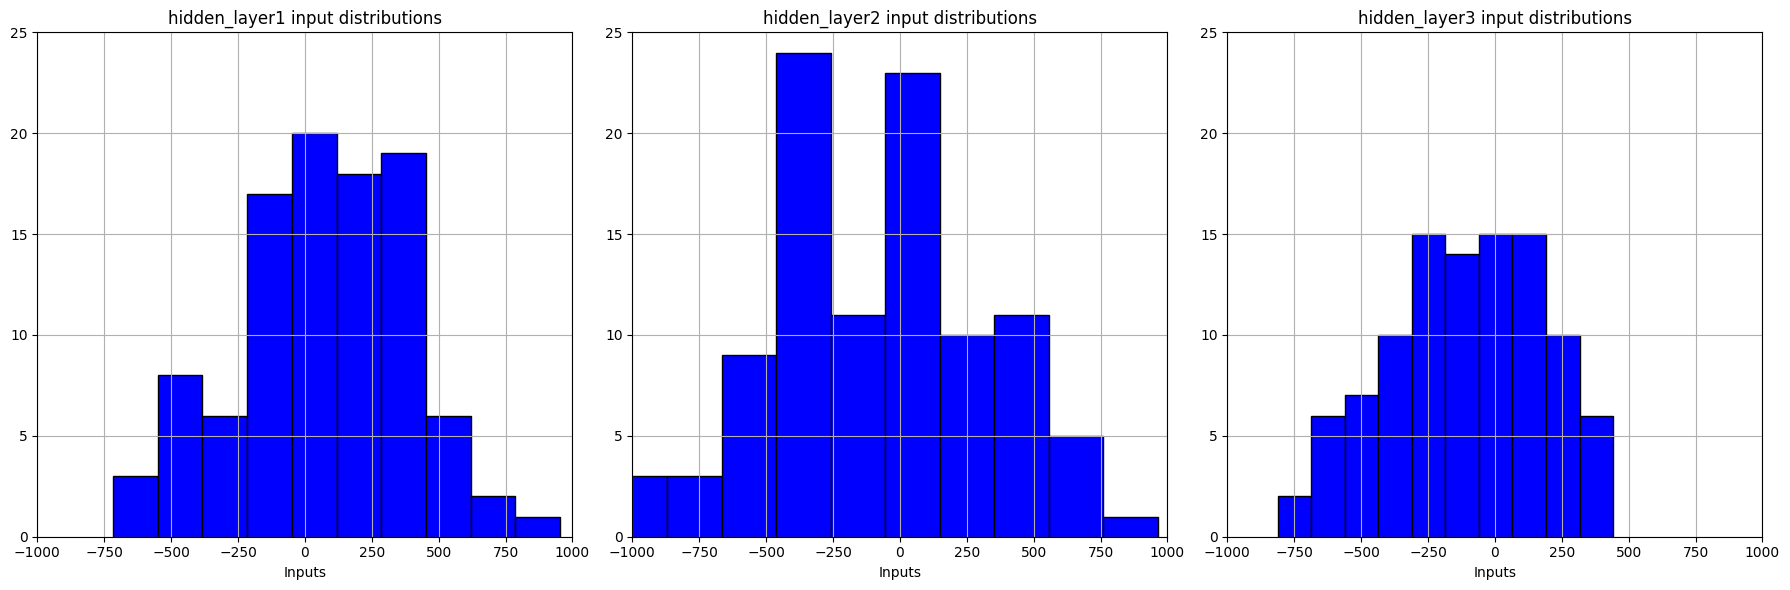

w1 std: 318.8673035960307, w1 mean: 72.89884081171965
w2 std: 390.312402953801, w2 mean: -73.52268457735377
w3 std: 280.0252475082474, w3 mean: -115.06551531387892


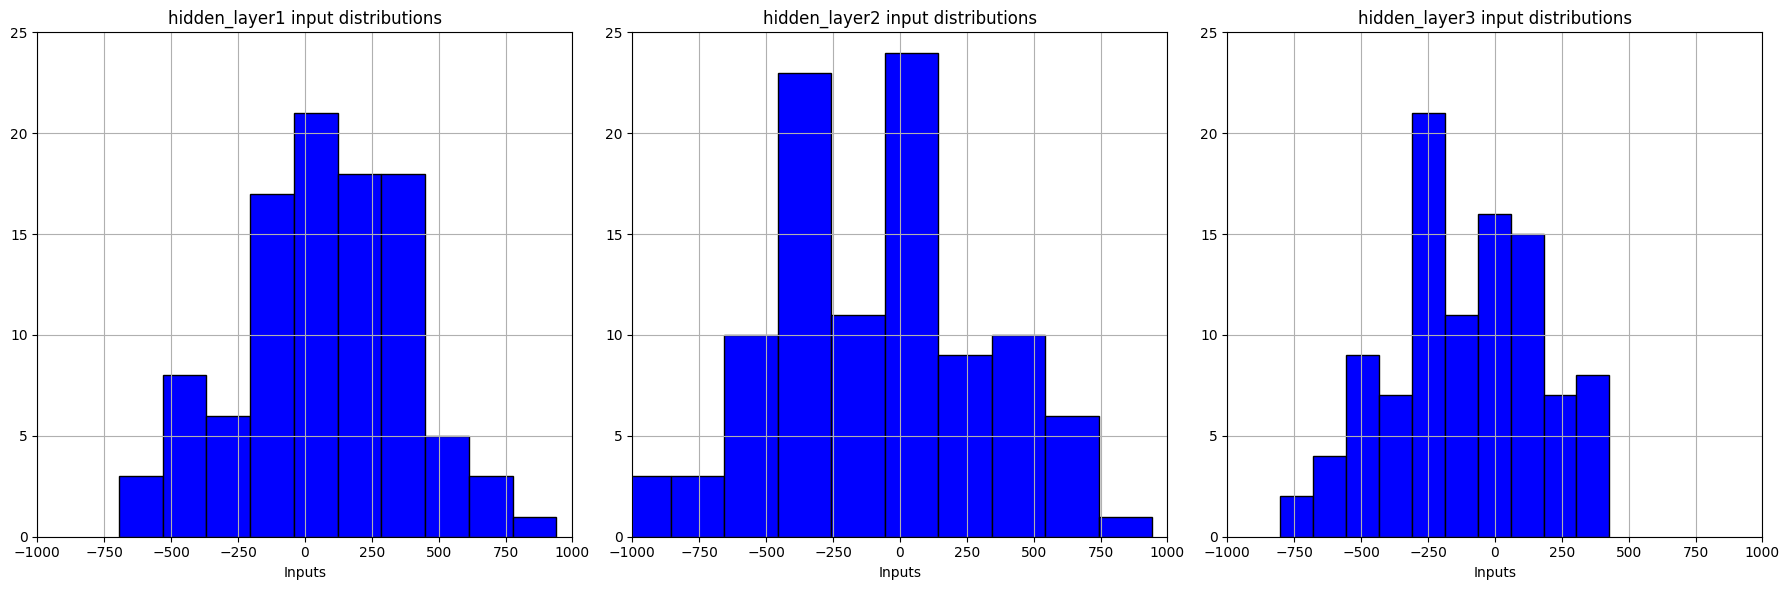

w1 std: 314.53178029410765, w1 mean: 74.90515184711634
w2 std: 388.43818071064476, w2 mean: -77.79268911954794
w3 std: 274.9086040316489, w3 mean: -120.47869956864491


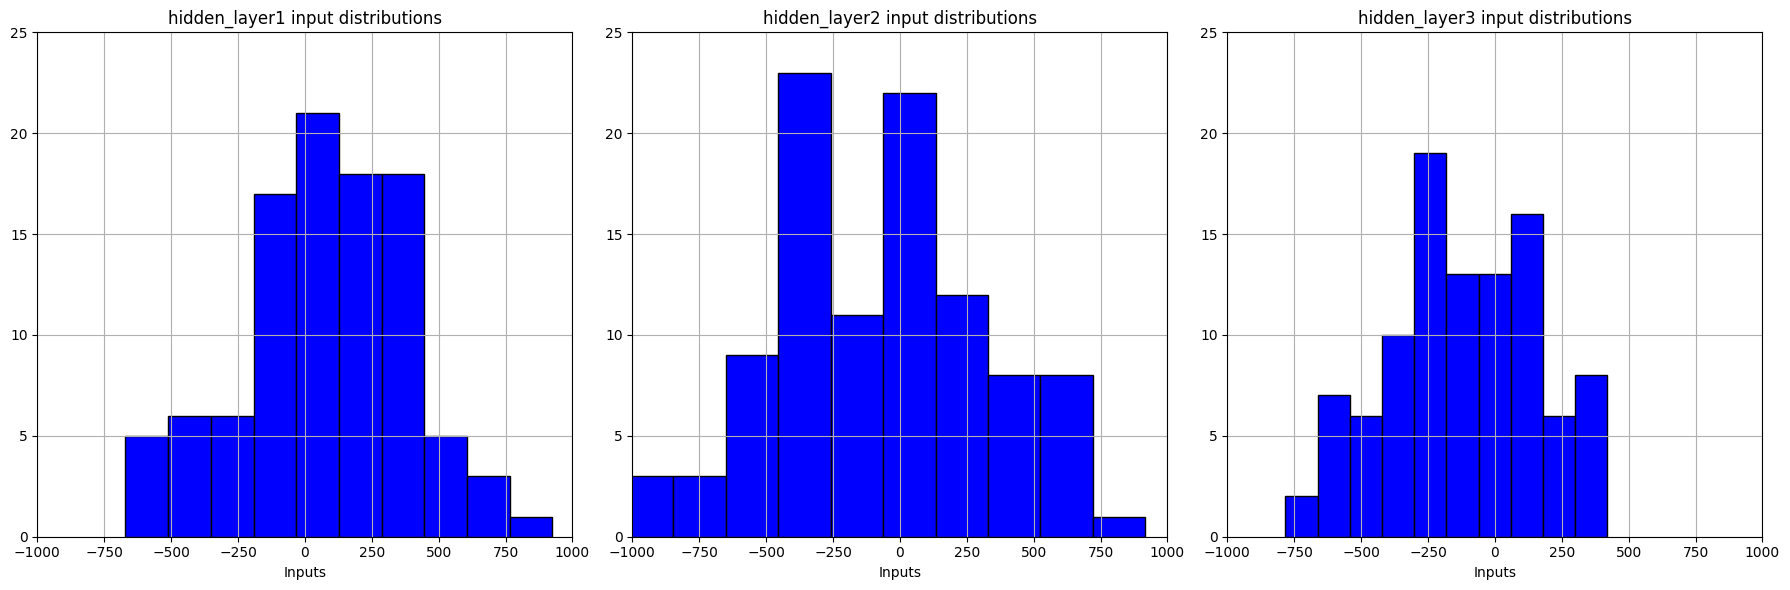

w1 std: 311.0871852977165, w1 mean: 76.18202465365245
w2 std: 384.6054354185384, w2 mean: -82.09946343933387
w3 std: 267.1881003389375, w3 mean: -125.22083454272797


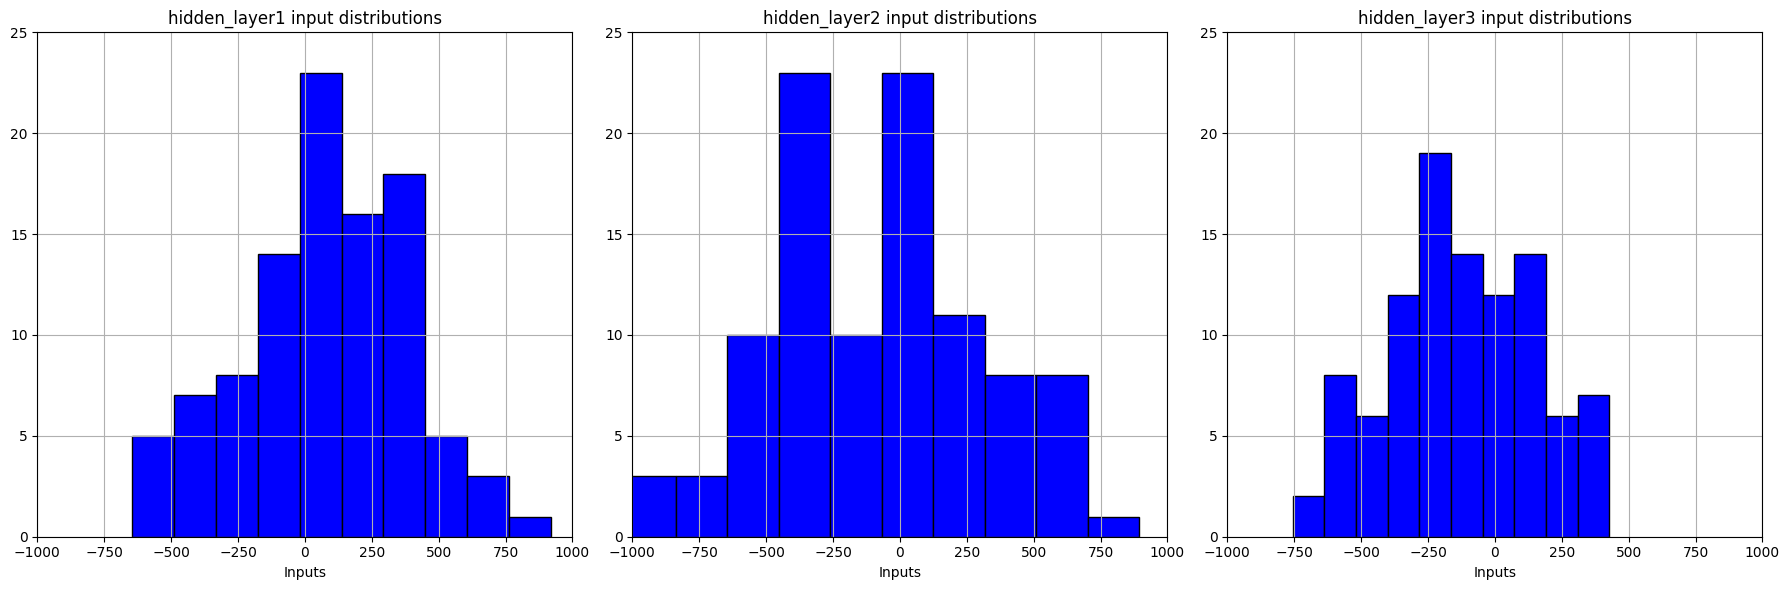

w1 std: 306.93416055407164, w1 mean: 77.04852278223206
w2 std: 379.8384554991863, w2 mean: -85.33395797554182
w3 std: 261.24805873641895, w3 mean: -131.0543693990736


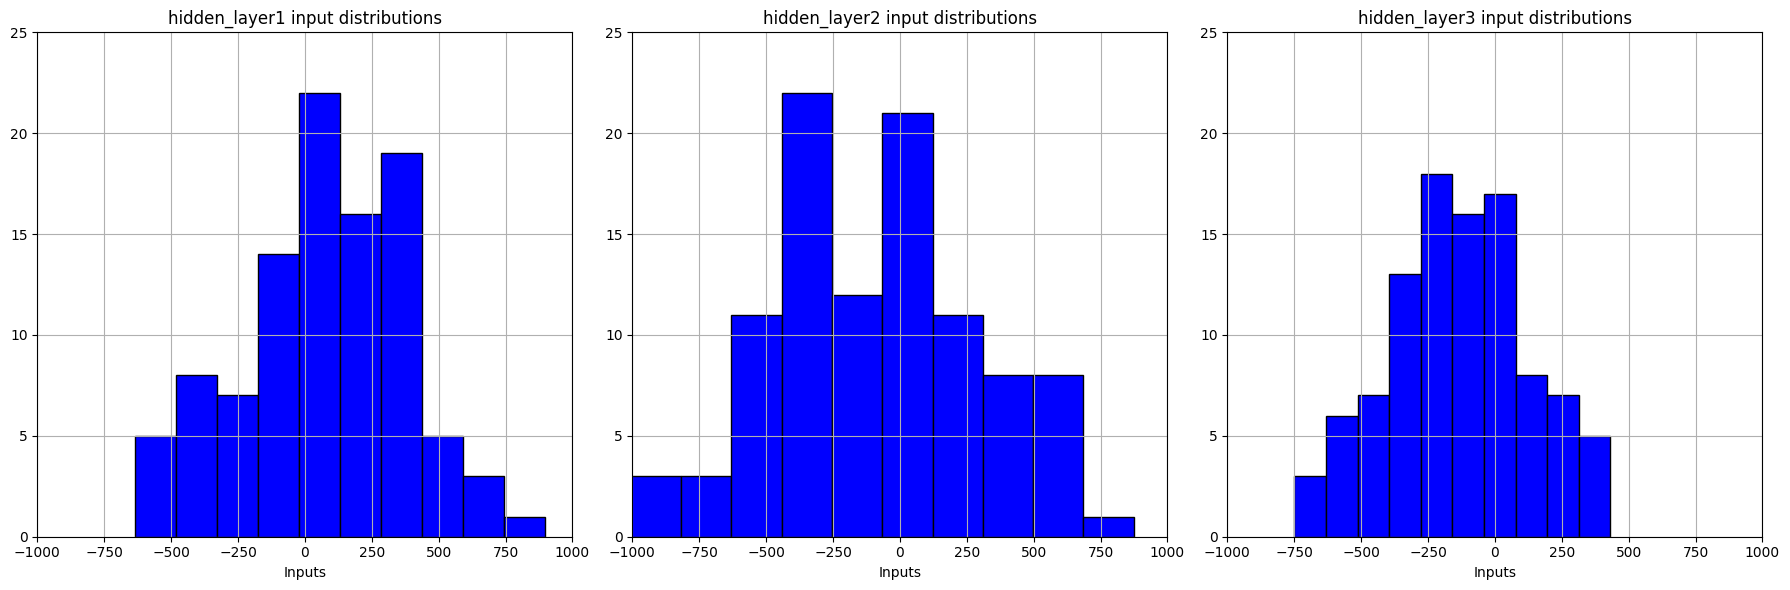

w1 std: 301.4819695690858, w1 mean: 78.54168845718142
w2 std: 374.421595894258, w2 mean: -87.84818076629648
w3 std: 254.17628073619613, w3 mean: -133.8336358637792


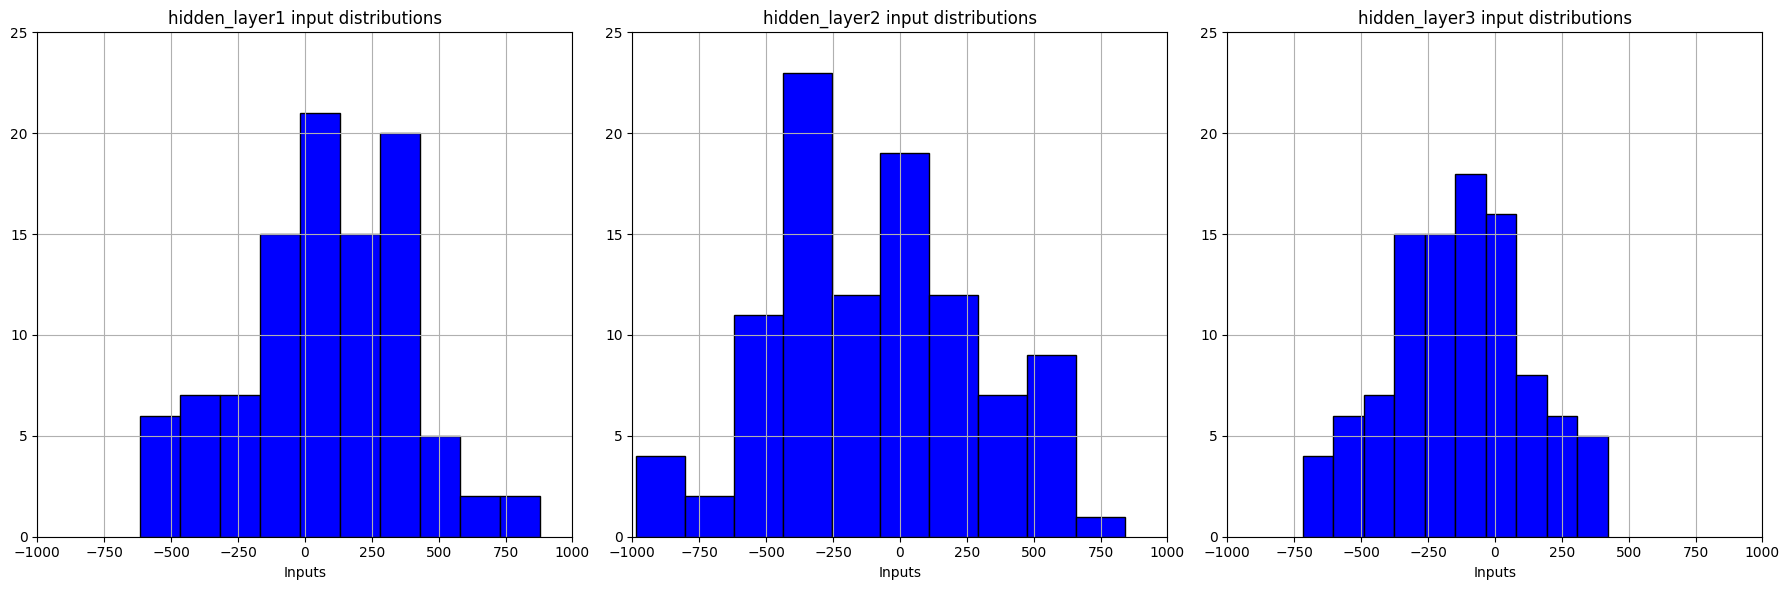

w1 std: 298.01532951317176, w1 mean: 79.28314128612965
w2 std: 370.82422815741273, w2 mean: -89.56657409291293
w3 std: 248.83943502097014, w3 mean: -136.9624696446769


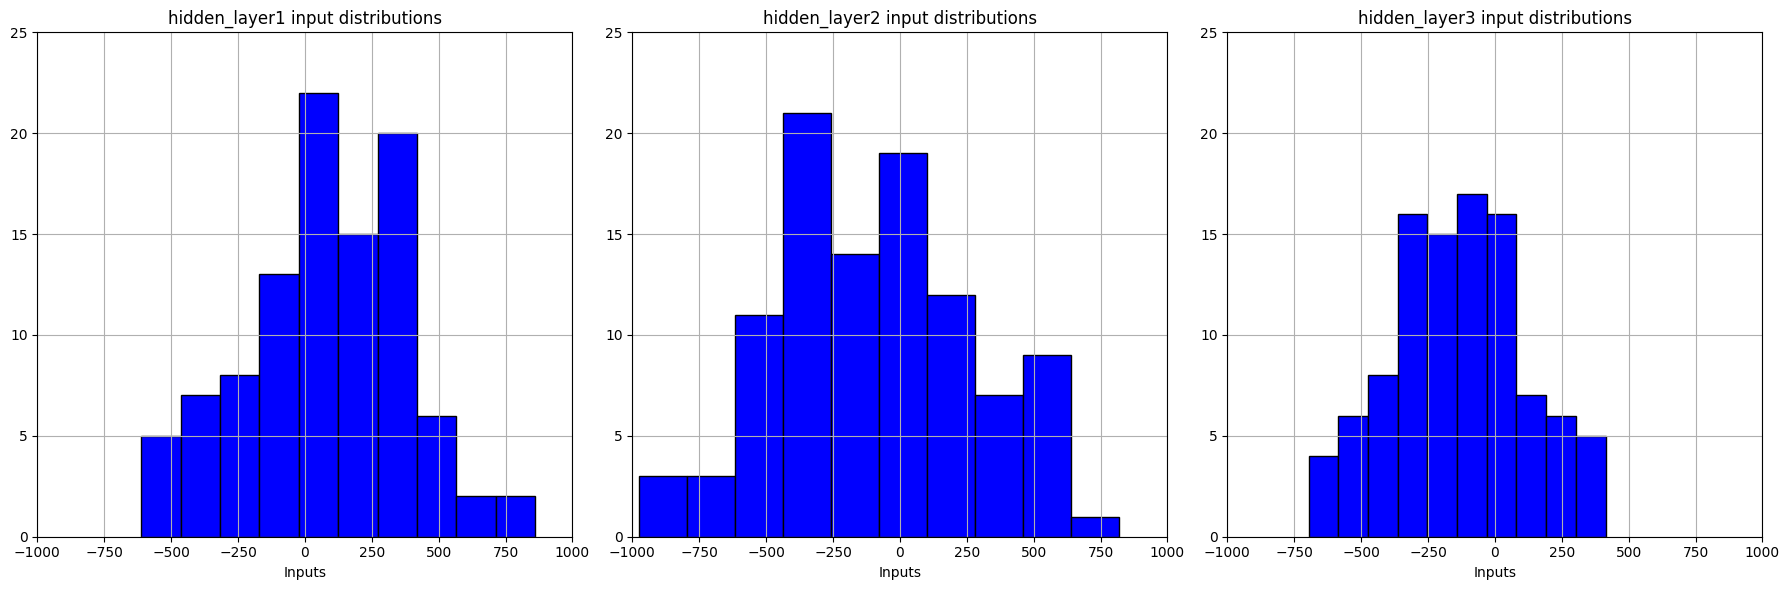

w1 std: 293.80769309536436, w1 mean: 80.42734220631043
w2 std: 368.548805566171, w2 mean: -91.95084813915857
w3 std: 244.76191149227873, w3 mean: -142.030690344166


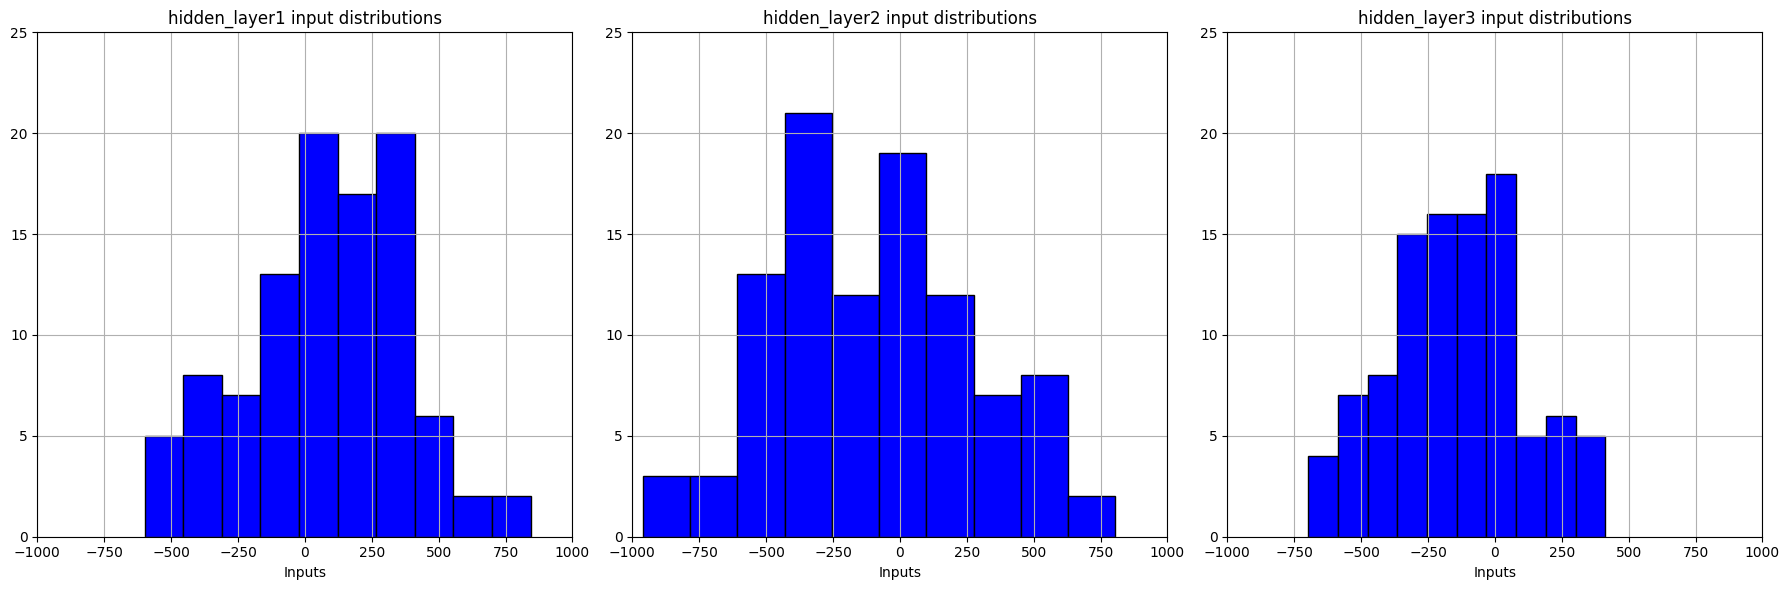

w1 std: 289.81065568427863, w1 mean: 81.59383405732147
w2 std: 364.2960039201836, w2 mean: -94.28671912889006
w3 std: 240.03475074042814, w3 mean: -144.1088334827807


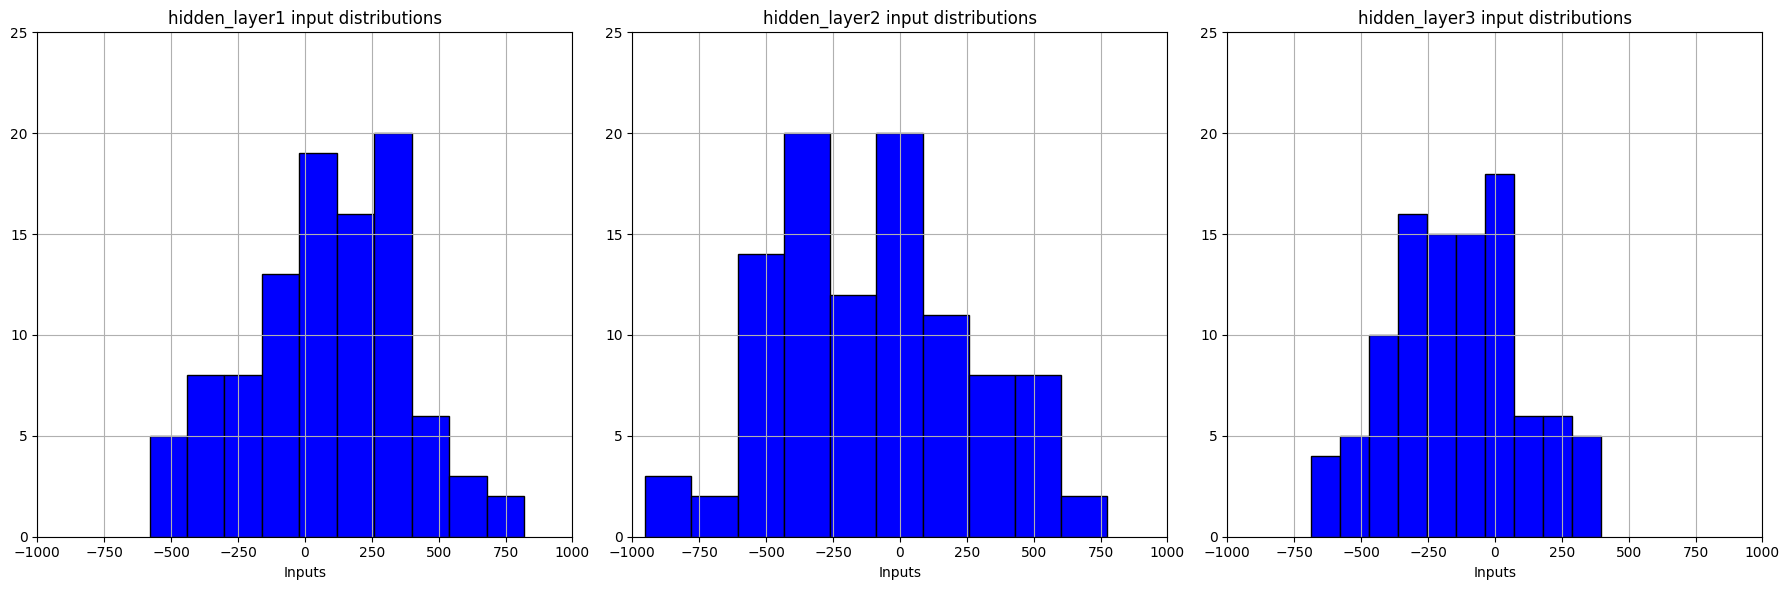

w1 std: 285.4811129353888, w1 mean: 82.55624050732466
w2 std: 359.9043954644317, w2 mean: -96.19480360677639
w3 std: 235.38596518169604, w3 mean: -146.2545049235511


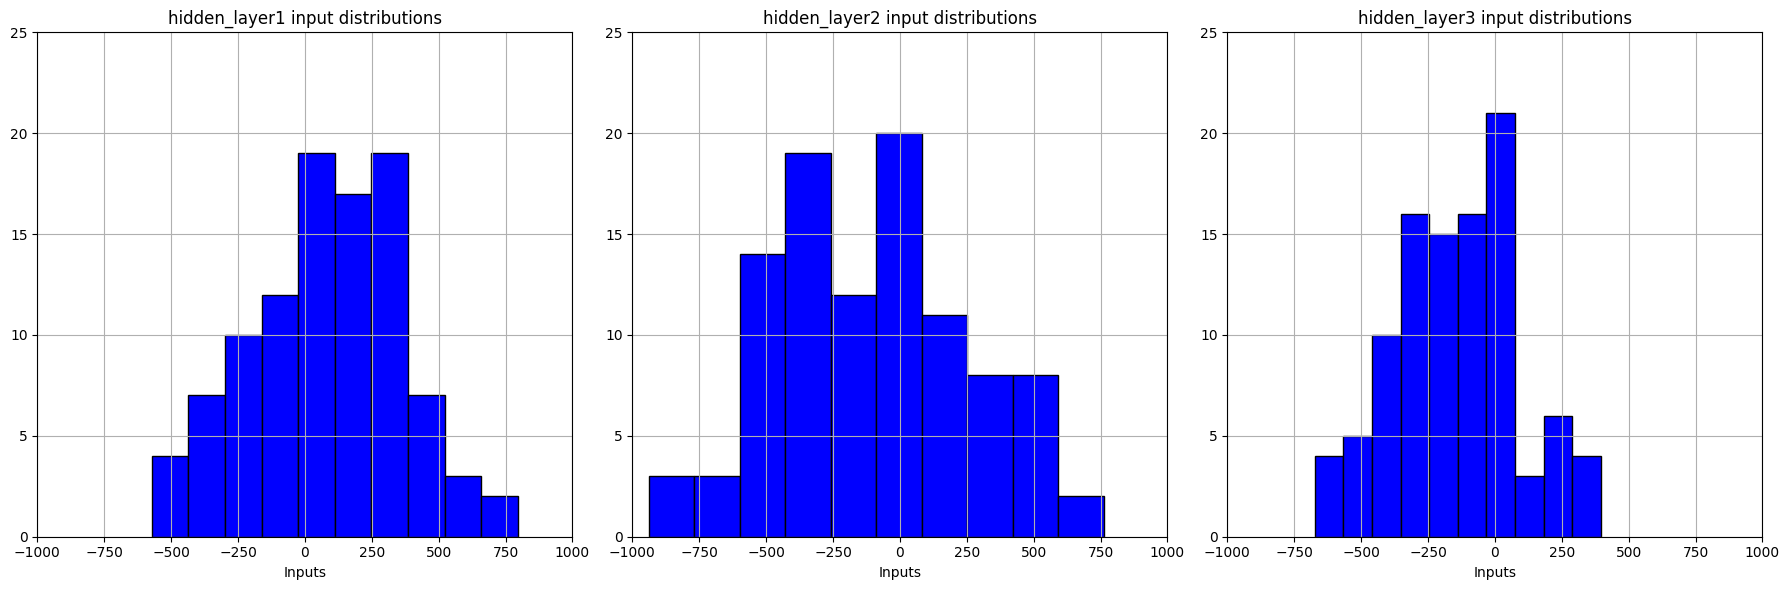

In [32]:
best_model = None

################################################################################
# TODO: Train the best FullyConnectedNet that you can on CIFAR-10. You might   #
# find batch/layer normalization and dropout useful. Store your best model in  #
# the best_model variable.                                                     #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

import time

best_val = -1
results = {}

def visualize_hiddendim_inputs(model):
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    w1 = model.cache_test[1][0].flatten()
    w2 = model.cache_test[3][0].flatten()
    w3 = model.cache_test[5][0].flatten()

    print(f'w1 std: {w1.std()}, w1 mean: {w1.mean()}')
    print(f'w2 std: {w2.std()}, w2 mean: {w2.mean()}')
    print(f'w3 std: {w3.std()}, w3 mean: {w3.mean()}')

    axs[0].hist(w1, color='blue', edgecolor='k')
    axs[0].set_title('hidden_layer1 input distributions')
    axs[0].set_xlabel('Inputs')
    axs[0].set_xlim(-1000, 1000)
    axs[0].set_ylim(0, 25)
    axs[0].grid(True)

    axs[1].hist(w2, color='blue', edgecolor='k')
    axs[1].set_title('hidden_layer2 input distributions')
    axs[1].set_xlabel('Inputs')
    axs[1].set_xlim(-1000, 1000)
    axs[1].set_ylim(0, 25)
    axs[1].grid(True)

    axs[2].hist(w3, color='blue', edgecolor='k')
    axs[2].set_title('hidden_layer3 input distributions')
    axs[2].set_xlabel('Inputs')
    axs[2].set_xlim(-1000, 1000)
    axs[2].set_ylim(0, 25)
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()


# set hyperparameters
lr = 10 ** np.random.uniform(-4.5, -3)
reg = 10 ** np.random.uniform(0, 0.3)
hidden_dims = [100, 100, 100]
print(f'lr: {lr:.4e}, reg: {reg:.4e}, hiddendim: {hidden_dims}')

# define model and solver
model = FullyConnectedNet(
    hidden_dims = hidden_dims,
    reg = reg,
    weight_scale = 1 / np.sqrt(50)
)
solver = Solver(
    model,
    data,
    update_rule = 'adam',
    optim_config = {
        'learning_rate': lr
    },
    batch_size = 1024,
    num_epochs = 1,
    verbose = False
)

# train
for _ in range(15):
    solver.train()
    visualize_hiddendim_inputs(model)


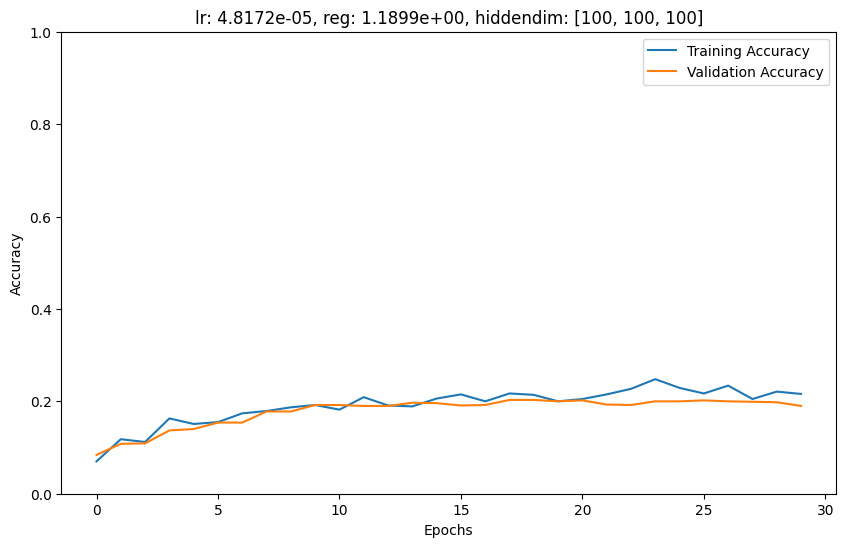

In [33]:
# score
plt.figure(figsize=(10, 6))
plt.plot(solver.train_acc_history, label='Training Accuracy')
plt.plot(solver.val_acc_history, label='Validation Accuracy')
plt.title(f'lr: {lr:.4e}, reg: {reg:.4e}, hiddendim: {hidden_dims}')
plt.ylim(0, 1)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()